# Entropy Analysis for DCA Models

Notebook purpose:
- Perform entropy and sequence-divergence analyses for four DCA model variants.
- Compare effective number of sequences (exp(entropy)), entropy per divergence bin,
  and energy / log-probability landscapes across models and divergence intervals.
- Produce publication-ready figures saved in the `images/` directory.

Models analyzed:
- **meDCA**: Maximum Entropy DCA (decimation path end)
- **eaDCA**: Edge Activation DCA
- **edDCA**: Edge-decimated DCA
- **bmDCA**: Boltzmann Machine DCA (fully connected)

Conventions and provenance:
- `dist_*` arrays: minimum Hamming distance from each generated sequence to the closest
  sequence in the natural MSA (precomputed and loaded from `entropy_logP_distance_arrays/`).
- `S_*_interval`: Shannon entropy values computed per divergence interval (9 bins).
- `logP_X_Y` naming: sequences from model X scored by model Y's energy function (log P_Y).
- Sequence length used throughout: L = 96 (Chorismate Mutase alignment).

The notebook contains self-contained plotting functions that reproduce the figures used in the paper.

# 1. Setup and Configuration

Import required libraries, set plotting style and load adabmDCA modules.

Notes:
- The notebook uses PyTorch for tensor ops and NumPy/Pandas for data handling.
- All plotting functions are configured for LaTeX-style figures suitable for
  inclusion in the paper (high DPI, consistent palettes, and font settings).
- Where possible, heavy computations (distance arrays, logP scores) are precomputed
  and loaded from disk to keep the notebook responsive and reproducible.


In [1]:
import argparse
import copy
import time
import os
from pathlib import Path
from typing import Dict

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.patches import Patch
from matplotlib.patches import Patch
from tqdm import tqdm
from torch.nn.functional import one_hot as one_hot_torch

# ===============================================================================
# adabmDCA modules for sequence analysis and DCA model operations
# ===============================================================================
# These modules provide functionality for:
# - FASTA file I/O and sequence weighting
# - Model parameter loading and chain sampling
# - Dataset handling for DCA training
# - Energy computation and statistical mechanics
# - Frequency and correlation analysis
# ===============================================================================

from adabmDCA.fasta import (
    get_tokens,              # Extract amino acid tokens from sequences
    import_from_fasta,       # Load sequences from FASTA files
    compute_weights,         # Compute sequence weights for reweighting
    write_fasta,             # Write sequences to FASTA format
)
from adabmDCA.io import load_params, load_chains  # Load model parameters and MCMC chains
from adabmDCA.dataset import DatasetDCA           # Dataset wrapper for DCA models
from adabmDCA.utils import (
    init_parameters,         # Initialize model parameters
    init_chains,             # Initialize MCMC chains
    resample_sequences,      # Resample sequences with replacement
    get_device,              # Get computational device (CPU/GPU)
    get_dtype,               # Get data type (float32/float64)
)
from adabmDCA.functional import one_hot           # One-hot encoding for sequences
from adabmDCA.statmech import compute_energy      # Compute energy of sequences
from adabmDCA.stats import (
    get_freq_single_point,       # Single-site amino acid frequencies
    get_freq_two_points,         # Two-site joint frequencies
    get_correlation_two_points,  # Two-site correlations
)
import seaborn as sns

# ===============================================================================
# Configure computational environment
# ===============================================================================
# Hardware and numeric precision choices used in the notebook. For reproducibility,
# we explicitly choose CPU execution and 32-bit floats; users with a CUDA-enabled
# GPU can replace the device selection by calling `get_device('cuda')` where needed.
device = get_device("cpu")      # Use CPU for computations
dtype = get_dtype("float32")    # Use 32-bit floating point precision
# Sequence length (used to normalize Hamming distances to fractional divergence):
# L = 96 (Chorismate Mutase alignment used in the manuscript)


Running on CPU


## Distance Utility

Define a chunked minimum-Hamming-distance helper used to compare generated samples with the natural MSA without materializing a prohibitively large full distance matrix.


In [2]:
def compute_min_distance(a1: torch.Tensor, a2: torch.Tensor, chunk_n: int = 100000) -> torch.Tensor:
    """
    Computes the minimum Hamming distance between each sequence in `a1` and all sequences in `a2`.
    
    This function processes sequences in chunks to manage memory efficiently when dealing with
    large sequence sets. The Hamming distance is computed by counting mismatches between
    one-hot encoded sequences.
    
    Args:
        a1: Tensor of shape (N, L, C) containing one-hot encoded sequences to query
        a2: Tensor of shape (M, L, C) containing one-hot encoded reference sequences
        chunk_n: Number of sequences from a1 to process simultaneously
        
    Returns:
        Tensor of shape (N,) containing minimum Hamming distance to nearest sequence in a2
    """
    N, L, C = a1.shape  # Extract dimensions: N sequences, length L, C amino acid classes
    M = a2.size(0)      # Number of reference sequences

    # Flatten one-hot encoded sequences along sequence length and amino acid dimensions
    # This converts (N, L, C) → (N, L*C) for efficient matrix multiplication
    a1f = a1.to(torch.float32).reshape(N, L * C).contiguous()
    a2f_t = a2.to(torch.float32).reshape(M, L * C).transpose(0, 1).contiguous()

    # Initialize minimum distances to maximum possible value (sequence length L)
    min_dist = torch.full((N,), L, device=a1.device, dtype=torch.int32)

    # Process sequences in chunks to avoid memory overflow
    n = 0
    while n < N:
        n_end = min(n + chunk_n, N)  # Process up to chunk_n sequences at a time

        # Compute dot product: number of matching positions between sequences
        # Matrix multiplication: (chunk_size, L*C) @ (L*C, M) → (chunk_size, M)
        matches = torch.matmul(a1f[n:n_end], a2f_t)
        
        # Convert matches to Hamming distances: distance = L - matches
        dblock = (L - matches).to(torch.int32)

        # Find minimum distance across all reference sequences for each query
        block_min = dblock.min(dim=1).values
        min_dist[n:n_end] = block_min  # Update minimum distances

        n = n_end  # Move to next chunk

    return min_dist


def compute_min_distance_batch(a1: torch.Tensor, a2: torch.Tensor, chunk_n: int = 100000) -> torch.Tensor:
    """
    Computes the minimum Hamming distance between each sequence in `a1` and all sequences in `a2`.
    
    This variant converts integer-encoded sequences in a1 to one-hot encoding on-the-fly within
    each batch, allowing for more memory-efficient storage of query sequences.
    
    Args:
        a1: Tensor of shape (N, L) containing integer-encoded sequences (0 to C-1)
        a2: Tensor of shape (M, L, C) containing one-hot encoded reference sequences
        chunk_n: Number of sequences from a1 to process simultaneously
        
    Returns:
        Tensor of shape (N,) containing minimum Hamming distance to nearest sequence in a2
    """
    N, L = a1.shape     # Extract dimensions: N sequences, length L
    M = a2.size(0)      # Number of reference sequences
    C = a2.size(-1)     # Number of amino acid classes (from one-hot dimension)

    # Initialize minimum distances to maximum possible value
    min_dist = torch.full((N,), L, device=a1.device, dtype=torch.int32)

    # Process sequences in batches
    n = 0
    while n < N:
        n_end = min(n + chunk_n, N)  # Process up to chunk_n sequences at a time

        # Convert current batch from integer encoding to one-hot encoding
        batch = a1[n:n_end]
        batch_onehot = torch.nn.functional.one_hot(batch.long(), num_classes=C).to(torch.float32)

        # Flatten one-hot encoded sequences for matrix multiplication
        n_batch = batch_onehot.size(0)
        a1f = batch_onehot.reshape(n_batch, L * C).contiguous()
        a2f_t = a2.reshape(M, L * C).transpose(0, 1).contiguous()

        # Compute matches and convert to Hamming distances
        matches = torch.matmul(a1f, a2f_t)
        dblock = (L - matches).to(torch.int32)

        # Find minimum distance for each sequence in the batch
        block_min = dblock.min(dim=1).values
        min_dist[n:n_end] = block_min

        n = n_end  # Move to next batch

    return min_dist


def compute_energy_in_batches(sequences, model, batch_size=64, device="cpu"):
    """
    Computes the average energy of a set of sequences in batches.
    
    This function processes sequences in batches to compute their energies under a DCA model,
    useful for evaluating large sets of sequences without memory overflow.
    
    Args:
        sequences: Tensor of integer-encoded sequences
        model: Dictionary containing DCA model parameters (h, J)
        batch_size: Number of sequences to process simultaneously
        device: Device for computation ('cpu' or 'cuda')
        
    Returns:
        Float value representing the mean energy across all sequences
    """
    n = len(sequences)  # Total number of sequences
    energies = []       # List to accumulate computed energies
    C = 21              # Number of amino acid classes (20 standard + gap)

    # Process sequences in batches
    for i in range(0, n, batch_size):
        # Extract current batch of sequences
        batch = sequences[i:i+batch_size]

        # Convert batch to one-hot encoding for energy computation
        batch_onehot = torch.nn.functional.one_hot(batch.long(), num_classes=C).to(device=device, dtype=torch.float32)

        # Compute energy without gradient tracking (inference mode)
        with torch.no_grad():
            e = compute_energy(batch_onehot, model)  # Returns energy for each sequence
        energies.append(e.detach().cpu())  # Move to CPU and store

    # Concatenate all batch energies and compute overall mean
    energies = torch.cat(energies)
    return energies.mean().item()


def frequent_distances(dist_tensor, threshold=1000):
    """
    Finds the most frequent distances in a distance tensor.
    
    Useful for identifying commonly occurring Hamming distances between generated
    and natural sequences, which can reveal clustering patterns.
    
    Args:
        dist_tensor: Tensor containing Hamming distances
        threshold: Minimum count for a distance value to be considered "frequent"
        
    Returns:
        Tuple of (frequent_values, frequent_counts) containing distance values
        that occur more than threshold times and their respective counts
    """
    # Find unique distance values and count their occurrences
    unique_vals, counts = torch.unique(dist_tensor, return_counts=True)

    # Filter to keep only values exceeding the threshold count
    mask = counts > threshold
    frequent_vals = unique_vals[mask]
    frequent_counts = counts[mask]

    return frequent_vals, frequent_counts


## Shared Model Palette

Define the color palette used consistently across entropy, divergence, and cross-model scoring figures.


In [3]:
# ===============================================================================
# DEFINE CONSISTENT COLOR PALETTE FOR ALL FIGURES
# ===============================================================================
# Using Seaborn's "deep" palette provides visually distinct colors that work
# well in both digital and print formats. These colors are used consistently
# across all plots for each DCA model variant.
# ===============================================================================

palette = sns.color_palette("deep", 4)  # Get 4 distinct colors
colors = {
    'meDCA': palette[0],    # Maximum Entropy DCA - Cool blue (most constrained)
    'edDCA': palette[1],    # Edge-Decimated DCA - Violet-pink (intermediate)
    'bmDCA': palette[2],    # Boltzmann Machine DCA - Pink-orange (fully connected)
    'eaDCA': palette[3]     # Edge Activation DCA - Warm red (least constrained)
}

output_path = "images/" 
os.makedirs(output_path, exist_ok=True)

# 2. Data Loading

Load pre-computed entropy values, distance arrays, and filtered data for analysis.

In [4]:
# ===============================================================================
# NATURAL SEQUENCE ENTROPY VALUES (MSA Entropy)
# ===============================================================================
# These represent the Shannon entropy of the natural multiple sequence alignment
# used to train each DCA model. Entropy quantifies sequence diversity:
#   - Lower entropy → more conserved, constrained sequence space
#   - Higher entropy → more diverse, less constrained sequence space
#
# The different values reflect how each model architecture captures the natural
# sequence distribution during training.
# ===============================================================================

S_msa_meDCA   = 0.494  # meDCA: Minimum entropy model (most constrained)
S_msa_eaDCA   = 1.533  # eaDCA: Highest entropy (least constrained)
S_msa_bmDCA   = 0.922  # bmDCA: Fully-connected Boltzmann machine
S_msa_edDCA   = 0.809  # edDCA: Edge-decimated model (intermediate constraints)


## Distance from Natural Sequences
Compute Hamming distance from each generated sequence to the closest natural sequence

In [5]:
# ===============================================================================
# LOAD PRE-COMPUTED HAMMING DISTANCES
# ===============================================================================
# These arrays contain the minimum Hamming distance from each generated sequence
# to the closest sequence in the natural MSA. Hamming distance measures the
# number of positions that differ between two sequences.
#
# These distances quantify how far generated sequences have diverged from the
# natural sequence space learned during training.
# ===============================================================================

# Directory containing all pre-computed distance arrays
output_dir = Path("entropy_logP_distance_arrays")

# Load minimum Hamming distances for each model's generated sequences
dist_meDCA = np.load(output_dir / "dist_meDCA.npy") # meDCA: maximum entropy model
dist_bmDCA = np.load(output_dir / "dist_bmDCA.npy") # bmDCA: Boltzmann machine
dist_eaDCA = np.load(output_dir / "dist_eaDCA.npy") # eaDCA: edge activation
dist_edDCA = np.load(output_dir / "dist_edDCA.npy") # edDCA: edge-decimated


## Filtered Distance Data
Load pre-filtered distance intervals (0.2-0.65 sequence divergence)

## Binned Divergence Intervals

Group generated sequences into sequence-divergence bins before comparing entropy estimates across models.


In [6]:
# ===============================================================================
# LOAD ENTROPY VALUES FOR DIVERGENCE INTERVALS
# ===============================================================================
# These arrays contain Shannon entropy values computed for sequences generated
# by each model, grouped into divergence bins (intervals defined below).
# Each array has 9 elements corresponding to 9 divergence intervals.
# ===============================================================================

S_meDCA_interval = np.load(output_dir / "S_meDCA_sample_interval.npy") # meDCA entropy per bin
S_eaDCA_interval = np.load(output_dir / "S_eaDCA_sample_interval.npy") # eaDCA entropy per bin
S_edDCA_interval = np.load(output_dir / "S_edDCA_sample_interval.npy") # edDCA entropy per bin
S_bmDCA_interval = np.load(output_dir / "S_bmDCA_sample_interval.npy") # bmDCA entropy per bin

# ===============================================================================
# FUNCTIONAL RATES AT THREE DIVERGENCE LEVELS
# ===============================================================================
# Fraction of sequences that retain biological function after experimental
# validation at three divergence ranges: low (0.2-0.25), medium (0.4-0.45),
# and high (0.6-0.65). These are empirically measured values.
# ===============================================================================

f_rate_meDCA = [0.309, 0.0520, 0.004]   # meDCA: drops sharply with divergence
f_rate_edDCA = [0.239, 0.052, 0.0]     # edDCA: no function at high divergence
f_rate_eaDCA = [0.318, 0.126, 0.02]  # eaDCA: best retention at high divergence
f_rate_bmDCA = [0.286, 0.119, 0.013]  # bmDCA: intermediate retention

# ===============================================================================
# DIVERGENCE INTERVALS FOR BINNED ANALYSIS
# ===============================================================================
# Sequences are grouped into 9 bins based on their Hamming distance from the
# closest natural sequence, expressed as fraction of sequence length.
# Each tuple represents (lower_bound, upper_bound) of sequence divergence.
# ===============================================================================

intervals = [(0.2, 0.25), (0.25, 0.3), (0.3, 0.35), (0.35, 0.4), 
             (0.4, 0.45), (0.45, 0.5), (0.5, 0.55), (0.55, 0.6), (0.6, 0.65)]

# ===============================================================================
# NORMALIZE DISTANCES TO SEQUENCE DIVERGENCE (0-1 SCALE)
# ===============================================================================
# Convert absolute Hamming distances to fractional divergence by dividing by
# sequence length (L=96 for Chorismate Mutase). This provides a normalized
# measure of sequence identity: 0 = identical, 1 = completely different.
# ===============================================================================

seq_div_meDCA = dist_meDCA / 96       # meDCA divergence (normalized)
seq_div_edDCA = dist_edDCA / 96       # edDCA divergence (normalized)
seq_div_bmDCA = dist_bmDCA / 96       # bmDCA divergence (normalized)
seq_div_eaDCA = dist_eaDCA / 96       # eaDCA divergence (normalized)


## Effective Number of Sequences Figure

Aggregate entropy estimates by divergence interval and plot the effective number of sequences, `exp(S)`, as a function of distance from the natural MSA.


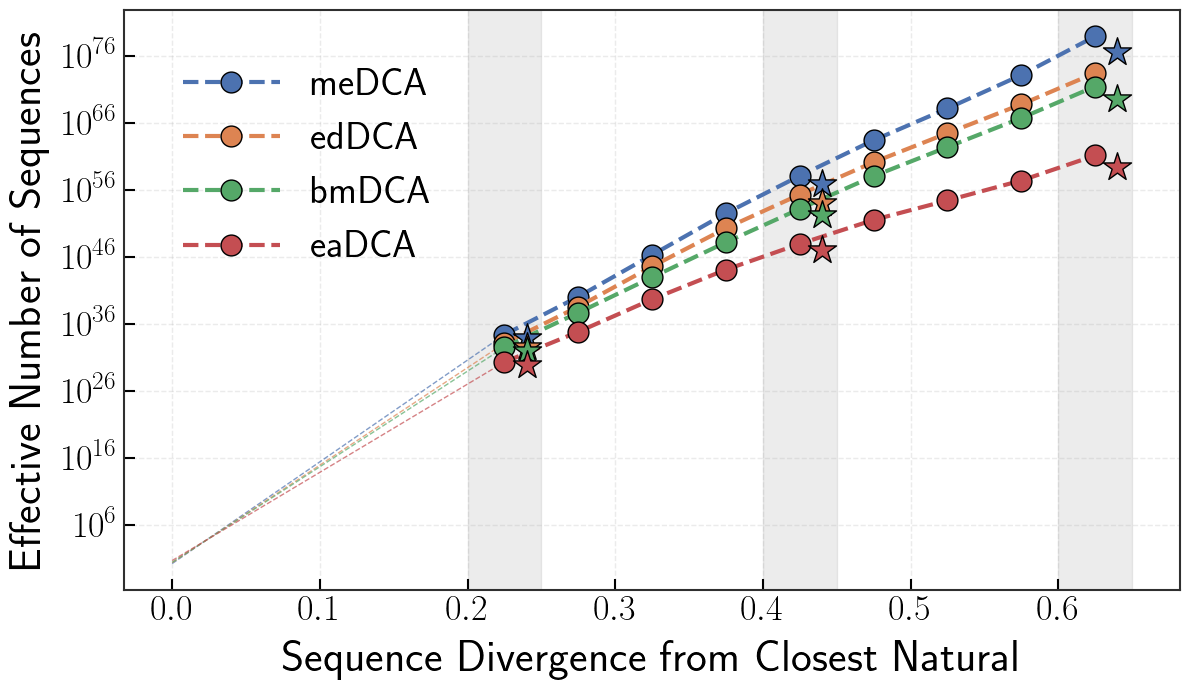

In [7]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# ===============================================================================
# MAIN FIGURE: Effective Number of Sequences vs Sequence Divergence
# ===============================================================================
# This figure shows how the effective number of sequences (exp(entropy)) changes
# as generated sequences diverge from natural ones. The star markers indicate
# the number of functional sequences at three divergence levels.
# ===============================================================================

# === LaTeX style configuration ===
plt.rcParams.update({
    "text.usetex": True,
    "font.weight": "normal",
    "axes.labelweight": "normal",
    "axes.titleweight": "normal",
    # "font.family": "serif",
    # "font.serif": ["Computer Modern Roman"],
    # "axes.linewidth": 1.2,
    # "xtick.direction": "in",
    # "ytick.direction": "in",
    # "xtick.top": True,
    # "ytick.right": True,
    # "xtick.major.size": 3.5,
    # "ytick.major.size": 3.5,
    # "xtick.minor.size": 2,
    # "ytick.minor.size": 2,
    # "axes.labelsize": 14,
    # "xtick.labelsize": 14,
    # "ytick.labelsize": 14,
    # "legend.frameon": False
})

# X-axis positions for divergence interval midpoints
x_plot = [0.225, 0.275, 0.325, 0.375, 0.425, 0.475, 0.525, 0.575, 0.625]
plt.figure(figsize=(12,7))

# === meDCA: Maximum Entropy DCA ===
# Connect MSA point (origin) to first divergence interval
x_meDCA = np.array([0, 0.225])
y_meDCA = np.exp(np.array([S_msa_meDCA, S_meDCA_interval[0]]))
plt.plot(x_meDCA, y_meDCA, linestyle="--", c=colors['meDCA'], linewidth=1, alpha=0.7)
# Plot entropy across all divergence intervals
plt.plot(x_plot, np.exp(S_meDCA_interval), marker="o", markersize=15, linewidth=3,
         c=colors['meDCA'], label="meDCA", markeredgewidth=1,
         markeredgecolor='black', linestyle="--")

# === edDCA: Edge-Decimated DCA ===
x_edDCA = np.array([0, 0.225])
y_edDCA = np.exp(np.array([S_msa_edDCA, S_edDCA_interval[0]]))
plt.plot(x_edDCA, y_edDCA, linestyle="--", c=colors['edDCA'], linewidth=1, alpha=0.7)
plt.plot(x_plot, np.exp(S_edDCA_interval), marker="o", markersize=15, linewidth=3,
         c=colors['edDCA'], label="edDCA", markeredgewidth=1,
         markeredgecolor='black', linestyle="--")

# === bmDCA: Boltzmann Machine DCA ===
x_bmDCA = np.array([0, 0.225])
y_bmDCA = np.exp(np.array([S_msa_bmDCA, S_bmDCA_interval[0]]))
plt.plot(x_bmDCA, y_bmDCA, linestyle="--", c=colors['bmDCA'], linewidth=1, alpha=0.7)
plt.plot(x_plot, np.exp(S_bmDCA_interval), marker="o", markersize=15, linewidth=3,
         c=colors['bmDCA'], label="bmDCA", markeredgewidth=1,
         markeredgecolor='black', linestyle="--")

# === eaDCA: Edge Activation DCA ===
x_eaDCA = np.array([0, 0.225])
y_eaDCA = np.exp(np.array([S_msa_eaDCA, S_eaDCA_interval[0]]))
plt.plot(x_eaDCA, y_eaDCA, linestyle="--", c=colors['eaDCA'], linewidth=1, alpha=0.7)
plt.plot(x_plot, np.exp(S_eaDCA_interval), marker="o", markersize=15, linewidth=3,
         c=colors['eaDCA'], label="eaDCA", markeredgewidth=1,
         markeredgecolor='black', linestyle="--")

# === Stars indicate functional sequences at three divergence levels ===
x_star = [0.24, 0.44, 0.64]  # Low, medium, high divergence

# meDCA functional rates
y_star_meDCA = np.array([
    np.exp(S_meDCA_interval[0]) * f_rate_meDCA[0],
    np.exp(S_meDCA_interval[4]) * f_rate_meDCA[1],
    np.exp(S_meDCA_interval[8]) * f_rate_meDCA[2]
])
plt.scatter(x_star, y_star_meDCA, marker="*", s=450,
            c=[colors['meDCA']], edgecolors="black", linewidth=1, zorder=10)

# edDCA functional rates
y_star_edDCA = np.array([
    np.exp(S_edDCA_interval[0]) * f_rate_edDCA[0],
    np.exp(S_edDCA_interval[4]) * f_rate_edDCA[1],
    np.exp(S_edDCA_interval[8]) * f_rate_edDCA[2]
])
plt.scatter(x_star, y_star_edDCA, marker="*", s=450,
            c=[colors['edDCA']], edgecolors="black", linewidth=1, zorder=10)

# bmDCA functional rates
y_star_bmDCA = np.array([
    np.exp(S_bmDCA_interval[0]) * f_rate_bmDCA[0],
    np.exp(S_bmDCA_interval[4]) * f_rate_bmDCA[1],
    np.exp(S_bmDCA_interval[8]) * f_rate_bmDCA[2]
])
plt.scatter(x_star, y_star_bmDCA, marker="*", s=450,
            c=[colors['bmDCA']], edgecolors="black", linewidth=1, zorder=10)

# eaDCA functional rates
y_star_eaDCA = np.array([
    np.exp(S_eaDCA_interval[0]) * f_rate_eaDCA[0],
    np.exp(S_eaDCA_interval[4]) * f_rate_eaDCA[1],
    np.exp(S_eaDCA_interval[8]) * f_rate_eaDCA[2]
])
plt.scatter(x_star, y_star_eaDCA, marker="*", s=450,
            c=[colors['eaDCA']], edgecolors="black", linewidth=1, zorder=10)

# === Layout and styling ===
plt.xlabel("Sequence Divergence from Closest Natural", fontsize=32, labelpad=10, fontweight="normal")
plt.ylabel("Effective Number of Sequences", fontsize=32, labelpad=10, fontweight="normal")

# Highlight three divergence ranges where functional rates were measured
plt.axvspan(0.2, 0.25, color='gray', alpha=0.15, zorder=0)
plt.axvspan(0.40, 0.45, color='gray', alpha=0.15, zorder=0)
plt.axvspan(0.60, 0.65, color='gray', alpha=0.15, zorder=0)

# Logarithmic scale for effective sequence numbers
plt.yscale('log')

# Legend configuration
plt.legend(prop={"size": 28, "weight": "normal"}, frameon=False, fancybox=False, shadow=False,
           framealpha=0.95, loc='best', borderpad=1, handlelength=2.5)

# Grid and tick styling
plt.grid(True, alpha=0.25, linestyle='--', linewidth=1)
plt.tick_params(axis='both', which='major', labelsize=16,
                direction='in', length=8, width=1.5)
plt.tick_params(axis='both', which='minor', labelsize=14,
                direction='in', length=4, width=1)
plt.xticks(fontsize=26, fontweight="normal")
plt.yticks(fontsize=26, fontweight="normal")

# Axis border styling
for spine in plt.gca().spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('#2F2F2F')

plt.tight_layout()
plt.savefig(output_path +"models_comparison_N_seq_noindep_fixed.pdf")
plt.show()


## Distribution of Sequence Divergence from Equilibrium Samples

In [8]:
# ===============================================================================
# COMPUTE SEQUENCE DIVERGENCE FROM NATURAL SEQUENCES
# ===============================================================================
# Convert Hamming distances to fractional divergence (0-1 scale) by dividing
# by sequence length (L=96). This normalization allows comparison across
# different sequence lengths and provides an intuitive measure of sequence
# identity: 0 = identical, 0.5 = 50% different, 1 = completely different.
# ===============================================================================

seq_div_meDCA = dist_meDCA / 96  # meDCA: sequences from maximum entropy model
seq_div_bmDCA = dist_bmDCA / 96  # bmDCA: sequences from fully-connected model
seq_div_eaDCA = dist_eaDCA / 96  # eaDCA: sequences from edge activation model
seq_div_edDCA = dist_edDCA / 96  # edDCA: sequences from edge-decimated model


## Divergence Distribution Figure

Create the publication-style plot showing how generated samples are distributed by sequence divergence from the closest natural sequence.


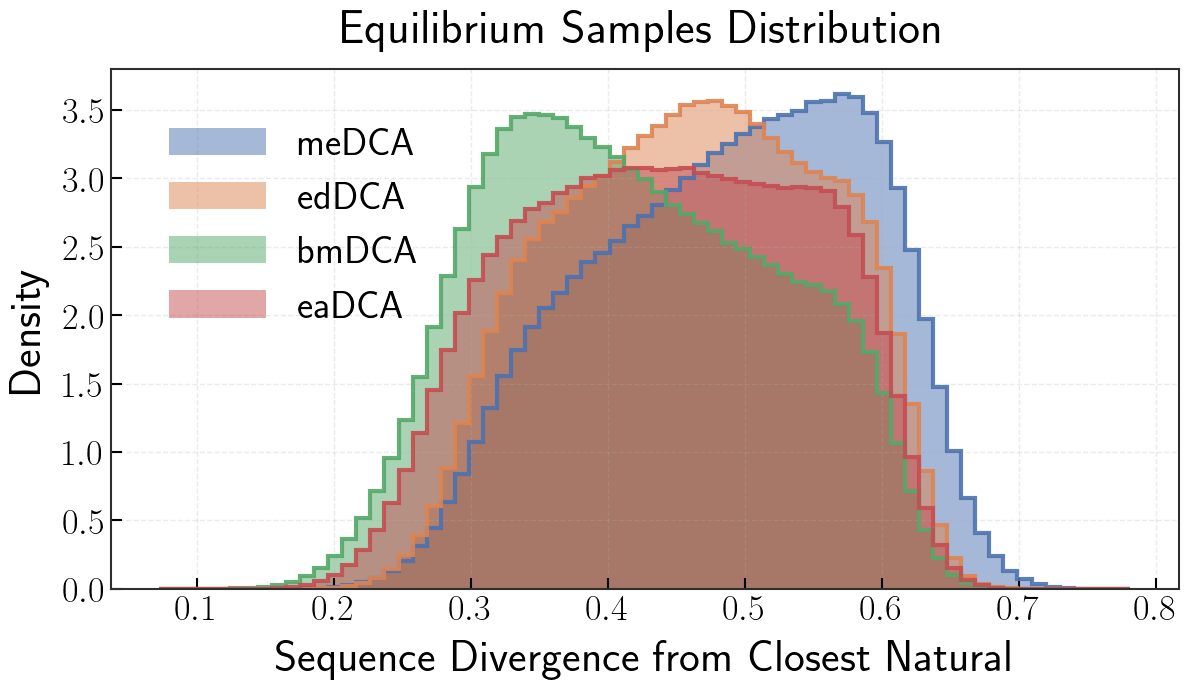

In [9]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

def plot_sequence_divergence_distribution(figsize=(12, 7)):
    """Plot sequence divergence distributions in LaTeX style consistent with other figures."""

    # === LaTeX style configuration ===
    plt.rcParams.update({
        "text.usetex": True,
        # "font.family": "serif",
        # "font.serif": ["Computer Modern Roman"],
        # "axes.linewidth": 1.2,
        # "xtick.direction": "in",
        # "ytick.direction": "in",
        # "xtick.top": True,
        # "ytick.right": True,
        # "xtick.major.size": 3.5,
        # "ytick.major.size": 3.5,
        # "xtick.minor.size": 2,
        # "ytick.minor.size": 2,
        # "axes.labelsize": 14,
        # "xtick.labelsize": 14,
        # "ytick.labelsize": 14,
        # "legend.frameon": False
    })

    # === Calculate common range and uniform bins across all models ===
    all_data = np.concatenate([seq_div_meDCA, seq_div_bmDCA, seq_div_eaDCA, seq_div_edDCA])
    num_bins = 70
    bins = np.linspace(all_data.min(), all_data.max(), num_bins)

    # === Create figure ===
    plt.figure(figsize=figsize)
  
    # === Aesthetic parameters ===
    alpha_fill = 0.5      # Transparency for filled histograms
    alpha_edge = 0.9      # Transparency for histogram edges
    linewidth = 3         # Width of histogram edges
    edgewidth = 1.5       # Width of axis borders

    # === meDCA: Maximum Entropy DCA ===
    # Filled histogram and outline for meDCA samples
    plt.hist(seq_div_meDCA, bins=bins, color=colors["meDCA"], alpha=alpha_fill,
             histtype="stepfilled", density=True, edgecolor="none", label=r"meDCA")
    plt.hist(seq_div_meDCA, bins=bins, color=colors["meDCA"], alpha=alpha_edge,
             histtype="step", linewidth=linewidth, density=True)

    # === edDCA: Edge-Decimated DCA ===
    plt.hist(seq_div_edDCA, bins=bins, color=colors["edDCA"], alpha=alpha_fill,
             histtype="stepfilled", density=True, edgecolor="none", label=r"edDCA")
    plt.hist(seq_div_edDCA, bins=bins, color=colors["edDCA"], alpha=alpha_edge,
             histtype="step", linewidth=linewidth, density=True,)

    # === bmDCA: Boltzmann Machine DCA ===
    plt.hist(seq_div_bmDCA, bins=bins, color=colors["bmDCA"], alpha=alpha_fill,
             histtype="stepfilled", density=True, edgecolor="none", label=r"bmDCA")
    plt.hist(seq_div_bmDCA, bins=bins, color=colors["bmDCA"], alpha=alpha_edge,
             histtype="step", linewidth=linewidth, density=True)

    # === eaDCA: Edge Activation DCA ===
    plt.hist(seq_div_eaDCA, bins=bins, color=colors["eaDCA"], alpha=alpha_fill,
             histtype="stepfilled", density=True, edgecolor="none", label=r"eaDCA")
    plt.hist(seq_div_eaDCA, bins=bins, color=colors["eaDCA"], alpha=alpha_edge,
             histtype="step", linewidth=linewidth, density=True)

    # === Title ===
    plt.title(r"Equilibrium Samples Distribution", fontsize=34, pad=20)

    # === Axis labels ===
    plt.xlabel(r"Sequence Divergence from Closest Natural", fontsize=32, labelpad=10)
    plt.ylabel(r"Density", fontsize=32, labelpad=10)

    # === Legend ===
    plt.legend(fontsize=28, frameon=False, fancybox=False, shadow=False,
               framealpha=0.95, loc='best', borderpad=1, handlelength=2.5)

    # === Grid and axes styling ===
    plt.grid(True, alpha=0.25, linestyle='--', linewidth=1)
    plt.tick_params(axis='both', which='major', labelsize=16,
                    direction='in', length=8, width=1.5)
    plt.tick_params(axis='both', which='minor', labelsize=14,
                    direction='in', length=4, width=1)
    plt.xticks(fontsize=26)
    plt.yticks(fontsize=26)

    # === Consistent axis border styling ===
    for spine in plt.gca().spines.values():
        spine.set_linewidth(1.5)
        spine.set_color('#2F2F2F')

    # === Layout and save ===
    plt.tight_layout()
    plt.savefig(output_path +"sequence_divergence_distribution_latex.pdf")
    plt.show()


# === Execute plotting function ===
plot_sequence_divergence_distribution()


# Cross-Model Scoring Analysis

## Evaluate sequences from one model using the energy function of another model

This section loads log-probability scores computed by evaluating sequences generated by each model using the probability distribution of every other model. This reveals how well models agree on sequence quality and identifies model-specific biases.

**Naming convention**: `logP_X_Y` = sequences from model X scored by model Y's energy function

In [10]:
# ===============================================================================
# LOAD CROSS-MODEL LOG-PROBABILITY SCORES
# ===============================================================================
# These arrays contain log-probability values computed by evaluating sequences
# from one model using the probability distribution of another model.
#
# Naming convention: logP_X_Y means:
#   - Sequences generated by model X
#   - Scored using model Y's energy function: log P_Y(seq) = -E_Y(seq) / T
#
# This cross-evaluation reveals how well different models agree on sequence
# quality and whether models have complementary or conflicting preferences.
# ===============================================================================

# === meDCA sequences scored by all four models ===
logP_meDCA_bmDCA = np.load(output_dir / "logP_meDCA_bmDCA.npy")  # meDCA seqs → bmDCA scoring
logP_meDCA_edDCA = np.load(output_dir / "logP_meDCA_edDCA.npy")  # meDCA seqs → edDCA scoring
logP_meDCA_eaDCA = np.load(output_dir / "logP_meDCA_eaDCA.npy")  # meDCA seqs → eaDCA scoring
logP_meDCA_meDCA = np.load(output_dir / "logP_meDCA_meDCA.npy")  # meDCA seqs → meDCA scoring (self)

# === edDCA sequences scored by all four models ===
logP_edDCA_bmDCA = np.load(output_dir / "logP_edDCA_bmDCA.npy")  # edDCA seqs → bmDCA scoring
logP_edDCA_edDCA = np.load(output_dir / "logP_edDCA_edDCA.npy")  # edDCA seqs → edDCA scoring (self)
logP_edDCA_eaDCA = np.load(output_dir / "logP_edDCA_eaDCA.npy")  # edDCA seqs → eaDCA scoring
logP_edDCA_meDCA = np.load(output_dir / "logP_edDCA_meDCA.npy")  # edDCA seqs → meDCA scoring

# === eaDCA sequences scored by all four models ===
logP_eaDCA_bmDCA = np.load(output_dir / "logP_eaDCA_bmDCA.npy")  # eaDCA seqs → bmDCA scoring
logP_eaDCA_edDCA = np.load(output_dir / "logP_eaDCA_edDCA.npy")  # eaDCA seqs → edDCA scoring
logP_eaDCA_meDCA = np.load(output_dir / "logP_eaDCA_meDCA.npy")  # eaDCA seqs → meDCA scoring
logP_eaDCA_eaDCA = np.load(output_dir / "logP_eaDCA_eaDCA.npy")  # eaDCA seqs → eaDCA scoring (self)

# === bmDCA sequences scored by all four models ===
logP_bmDCA_edDCA = np.load(output_dir / "logP_bmDCA_edDCA.npy")  # bmDCA seqs → edDCA scoring
logP_bmDCA_eaDCA = np.load(output_dir / "logP_bmDCA_eaDCA.npy")  # bmDCA seqs → eaDCA scoring
logP_bmDCA_meDCA = np.load(output_dir / "logP_bmDCA_meDCA.npy")  # bmDCA seqs → meDCA scoring
logP_bmDCA_bmDCA = np.load(output_dir / "logP_bmDCA_bmDCA.npy")  # bmDCA seqs → bmDCA scoring (self)


## Cross-Model Log-Probability Grid

Visualize how sequences sampled from each model are scored by the other models, exposing whether models assign compatible likelihoods to each other's samples.


/tmp/ipykernel_2301784/3039250628.py:53: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(seq_div_eaDCA[:n],   logP_eaDCA_eaDCA,    s=marker_size, c=colors['eaDCA'], alpha=alpha_point, label="eaDCA")
/tmp/ipykernel_2301784/3039250628.py:54: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(seq_div_bmDCA[:n], logP_bmDCA_eaDCA, s=marker_size, c=colors['bmDCA'], alpha=alpha_point, label="bmDCA")
/tmp/ipykernel_23

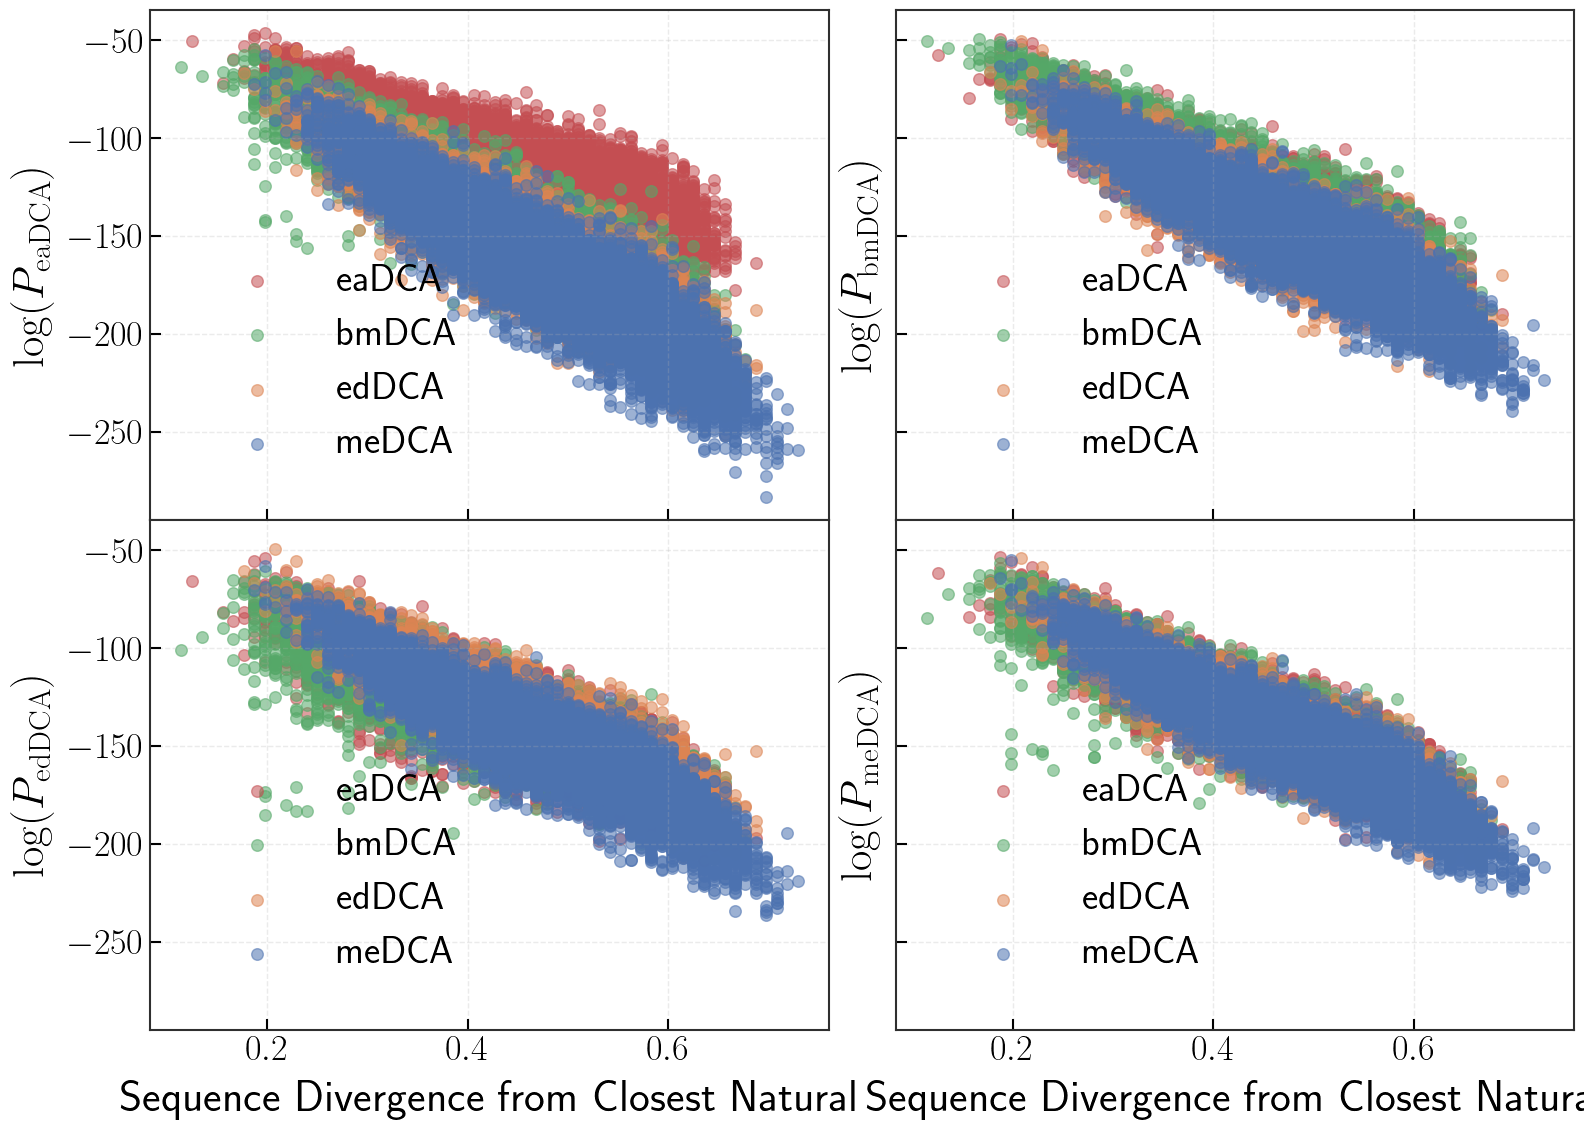

In [11]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Number of sequences to plot per model
n = logP_eaDCA_eaDCA.shape[0]

def plot_energy_comparison_grid(figsize=(16, 12)):
    """Create 2x2 grid plot in LaTeX style for cross-model energy comparison."""

    # === LaTeX style configuration ===
    plt.rcParams.update({
        "text.usetex": True,
        # "font.family": "serif",
        # "font.serif": ["Computer Modern Roman"],
        # "axes.linewidth": 1.2,
        # "xtick.direction": "in",
        # "ytick.direction": "in",
        # "xtick.top": True,
        # "ytick.right": True,
        # "xtick.major.size": 3.5,
        # "ytick.major.size": 3.5,
        # "xtick.minor.size": 2,
        # "ytick.minor.size": 2,
        # "axes.labelsize": 14,
        # "xtick.labelsize": 14,
        # "ytick.labelsize": 14,
        # "legend.frameon": False
    })

    # === Create 2x2 figure grid ===
    fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=True, sharey=True)
    plt.subplots_adjust(wspace=0.1, hspace=0.0, left=0.08, right=0.97, top=0.93, bottom=0.08)

    # === Aesthetic parameters ===
    marker_size = 70
    alpha_point = 0.55    # Transparency for scatter points
    grid_alpha = 0.25     # Grid transparency
    linewidth = 1.5       # Border line width

    # === Helper function for consistent axis styling ===
    def style_axes(ax):
        """Apply consistent styling to subplot axes."""
        ax.grid(True, alpha=grid_alpha, linestyle='--', linewidth=1)
        ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.5)
        ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1)
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
            spine.set_color('#2F2F2F')

    # === SUBPLOT 1: Sequences scored by eaDCA energy function ===
    ax = axes[0, 0]
    ax.scatter(seq_div_eaDCA[:n],   logP_eaDCA_eaDCA,    s=marker_size, c=colors['eaDCA'], alpha=alpha_point, label="eaDCA")
    ax.scatter(seq_div_bmDCA[:n], logP_bmDCA_eaDCA, s=marker_size, c=colors['bmDCA'], alpha=alpha_point, label="bmDCA")
    ax.scatter(seq_div_edDCA[:n],   logP_edDCA_eaDCA,   s=marker_size, c=colors['edDCA'], alpha=alpha_point, label="edDCA")
    ax.scatter(seq_div_meDCA[:n],    logP_meDCA_eaDCA,    s=marker_size, c=colors['meDCA'], alpha=alpha_point, label="meDCA")
    ax.set_ylabel(r"$\log(P_{\mathrm{eaDCA}})$", fontsize=32, labelpad=10)
    ax.legend(fontsize=28, frameon=False, fancybox=False, shadow=False, framealpha=0.95, borderpad=1, handlelength=2.5)
    ax.tick_params(axis='x', labelsize=26)
    ax.tick_params(axis='y', labelsize=26)
    style_axes(ax)

    # === SUBPLOT 2: Sequences scored by bmDCA energy function ===
    ax = axes[0, 1]
    ax.scatter(seq_div_eaDCA[:n],   logP_eaDCA_bmDCA,    s=marker_size, c=colors['eaDCA'], alpha=alpha_point, label="eaDCA")
    ax.scatter(seq_div_bmDCA[:n], logP_bmDCA_bmDCA, s=marker_size, c=colors['bmDCA'], alpha=alpha_point, label="bmDCA")
    ax.scatter(seq_div_edDCA[:n],   logP_edDCA_bmDCA,   s=marker_size, c=colors['edDCA'], alpha=alpha_point, label="edDCA")
    ax.scatter(seq_div_meDCA[:n],    logP_meDCA_bmDCA,    s=marker_size, c=colors['meDCA'], alpha=alpha_point, label="meDCA")
    ax.set_ylabel(r"$\log(P_{\mathrm{bmDCA}})$", fontsize=32, labelpad=10)
    ax.legend(fontsize=28, frameon=False, fancybox=False, shadow=False, framealpha=0.95, borderpad=1, handlelength=2.5)
    ax.tick_params(axis='x', labelsize=26)
    ax.tick_params(axis='y', labelsize=26)
    style_axes(ax)

    # === SUBPLOT 3: Sequences scored by edDCA energy function ===
    ax = axes[1, 0]
    ax.scatter(seq_div_eaDCA[:n],   logP_eaDCA_edDCA,    s=marker_size, c=colors['eaDCA'], alpha=alpha_point, label="eaDCA")
    ax.scatter(seq_div_bmDCA[:n], logP_bmDCA_edDCA, s=marker_size, c=colors['bmDCA'], alpha=alpha_point, label="bmDCA")
    ax.scatter(seq_div_edDCA[:n],   logP_edDCA_edDCA,   s=marker_size, c=colors['edDCA'], alpha=alpha_point, label="edDCA")
    ax.scatter(seq_div_meDCA[:n],    logP_meDCA_edDCA,    s=marker_size, c=colors['meDCA'], alpha=alpha_point, label="meDCA")
    ax.set_xlabel(r"Sequence Divergence from Closest Natural", fontsize=32, labelpad=10)
    ax.set_ylabel(r"$\log(P_{\mathrm{edDCA}})$", fontsize=32, labelpad=10)
    ax.legend(fontsize=28, frameon=False, fancybox=False, shadow=False, framealpha=0.95, borderpad=1, handlelength=2.5)
    ax.tick_params(axis='x', labelsize=26)
    ax.tick_params(axis='y', labelsize=26)
    style_axes(ax)

    # === SUBPLOT 4: Sequences scored by meDCA energy function ===
    ax = axes[1, 1]
    ax.scatter(seq_div_eaDCA[:n],   logP_eaDCA_meDCA,    s=marker_size, c=colors['eaDCA'], alpha=alpha_point, label="eaDCA")
    ax.scatter(seq_div_bmDCA[:n], logP_bmDCA_meDCA, s=marker_size, c=colors['bmDCA'], alpha=alpha_point, label="bmDCA")
    ax.scatter(seq_div_edDCA[:n],   logP_edDCA_meDCA,   s=marker_size, c=colors['edDCA'], alpha=alpha_point, label="edDCA")
    ax.scatter(seq_div_meDCA[:n],    logP_meDCA_meDCA,    s=marker_size, c=colors['meDCA'], alpha=alpha_point, label="meDCA")
    ax.set_xlabel(r"Sequence Divergence from Closest Natural", fontsize=32, labelpad=10)
    ax.set_ylabel(r"$\log(P_{\mathrm{meDCA}})$", fontsize=32, labelpad=10)
    ax.legend(fontsize=28, frameon=False, fancybox=False, shadow=False, framealpha=0.95, borderpad=1, handlelength=2.5)
    ax.tick_params(axis='x', labelsize=26)
    ax.tick_params(axis='y', labelsize=26)
    style_axes(ax)

    # === Final layout and save ===
    plt.savefig(output_path +"scatterplot_energy_vs_seqID.png")
    plt.show()


# === Execute plotting function ===
plot_energy_comparison_grid()


## Cross-Model Energy Arrays

Load the replicated energy evaluations used to compare distributions across scoring models and sampling models.


In [12]:
# ===============================================================================
# LOAD CROSS-MODEL ENERGY EVALUATIONS
# ===============================================================================
# These arrays contain energy values computed for sequences from one model
# evaluated using the energy function of another model.
# Naming convention: ene_X_Y_Z means:
#   - Sequences generated by model X
#   - Evaluated using model Y's energy function
#   - At divergence interval Z (1=low, 2=medium, 3=high divergence)
# ===============================================================================

# === meDCA sequences evaluated by all models, three divergence intervals ===
ene_meDCA_bmDCA_1 = np.load(output_dir / "ene_meDCA_bmDCA_1.npy")
ene_meDCA_edDCA_1   = np.load(output_dir / "ene_meDCA_edDCA_1.npy")
ene_meDCA_eaDCA_1    = np.load(output_dir / "ene_meDCA_eaDCA_1.npy")
ene_meDCA_meDCA_1    = np.load(output_dir / "ene_meDCA_meDCA_1.npy")

ene_meDCA_bmDCA_2 = np.load(output_dir / "ene_meDCA_bmDCA_2.npy")
ene_meDCA_edDCA_2   = np.load(output_dir / "ene_meDCA_edDCA_2.npy")
ene_meDCA_eaDCA_2    = np.load(output_dir / "ene_meDCA_eaDCA_2.npy")
ene_meDCA_meDCA_2    = np.load(output_dir / "ene_meDCA_meDCA_2.npy")

ene_meDCA_bmDCA_3 = np.load(output_dir / "ene_meDCA_bmDCA_3.npy")
ene_meDCA_edDCA_3   = np.load(output_dir / "ene_meDCA_edDCA_3.npy")
ene_meDCA_eaDCA_3    = np.load(output_dir / "ene_meDCA_eaDCA_3.npy")
ene_meDCA_meDCA_3    = np.load(output_dir / "ene_meDCA_meDCA_3.npy")

# === edDCA sequences evaluated by all models, three divergence intervals ===
ene_edDCA_bmDCA_1 = np.load(output_dir / "ene_edDCA_bmDCA_1.npy")
ene_edDCA_eaDCA_1    = np.load(output_dir / "ene_edDCA_eaDCA_1.npy")
ene_edDCA_meDCA_1    = np.load(output_dir / "ene_edDCA_meDCA_1.npy")
ene_edDCA_edDCA_1   = np.load(output_dir / "ene_edDCA_edDCA_1.npy")

ene_edDCA_bmDCA_2 = np.load(output_dir / "ene_edDCA_bmDCA_2.npy")
ene_edDCA_eaDCA_2    = np.load(output_dir / "ene_edDCA_eaDCA_2.npy")
ene_edDCA_meDCA_2    = np.load(output_dir / "ene_edDCA_meDCA_2.npy")
ene_edDCA_edDCA_2   = np.load(output_dir / "ene_edDCA_edDCA_2.npy")

ene_edDCA_bmDCA_3 = np.load(output_dir / "ene_edDCA_bmDCA_3.npy")
ene_edDCA_eaDCA_3    = np.load(output_dir / "ene_edDCA_eaDCA_3.npy")
ene_edDCA_meDCA_3    = np.load(output_dir / "ene_edDCA_meDCA_3.npy")
ene_edDCA_edDCA_3   = np.load(output_dir / "ene_edDCA_edDCA_3.npy")

# === eaDCA sequences evaluated by all models, three divergence intervals ===
ene_eaDCA_bmDCA_1  = np.load(output_dir / "ene_eaDCA_bmDCA_1.npy")
ene_eaDCA_edDCA_1    = np.load(output_dir / "ene_eaDCA_edDCA_1.npy")
ene_eaDCA_meDCA_1     = np.load(output_dir / "ene_eaDCA_meDCA_1.npy")
ene_eaDCA_eaDCA_1     = np.load(output_dir / "ene_eaDCA_eaDCA_1.npy")

ene_eaDCA_bmDCA_2  = np.load(output_dir / "ene_eaDCA_bmDCA_2.npy")
ene_eaDCA_edDCA_2    = np.load(output_dir / "ene_eaDCA_edDCA_2.npy")
ene_eaDCA_meDCA_2     = np.load(output_dir / "ene_eaDCA_meDCA_2.npy")
ene_eaDCA_eaDCA_2     = np.load(output_dir / "ene_eaDCA_eaDCA_2.npy")

ene_eaDCA_bmDCA_3  = np.load(output_dir / "ene_eaDCA_bmDCA_3.npy")
ene_eaDCA_edDCA_3    = np.load(output_dir / "ene_eaDCA_edDCA_3.npy")
ene_eaDCA_meDCA_3     = np.load(output_dir / "ene_eaDCA_meDCA_3.npy")
ene_eaDCA_eaDCA_3     = np.load(output_dir / "ene_eaDCA_eaDCA_3.npy")

# === bmDCA sequences evaluated by all models, three divergence intervals ===
ene_bmDCA_edDCA_1 = np.load(output_dir / "ene_bmDCA_edDCA_1.npy")
ene_bmDCA_eaDCA_1  = np.load(output_dir / "ene_bmDCA_eaDCA_1.npy")
ene_bmDCA_meDCA_1  = np.load(output_dir / "ene_bmDCA_meDCA_1.npy")
ene_bmDCA_bmDCA_1 = np.load(output_dir / "ene_bmDCA_bmDCA_1.npy")

ene_bmDCA_edDCA_2 = np.load(output_dir / "ene_bmDCA_edDCA_2.npy")
ene_bmDCA_eaDCA_2  = np.load(output_dir / "ene_bmDCA_eaDCA_2.npy")
ene_bmDCA_meDCA_2  = np.load(output_dir / "ene_bmDCA_meDCA_2.npy")
ene_bmDCA_bmDCA_2 = np.load(output_dir / "ene_bmDCA_bmDCA_2.npy")

ene_bmDCA_edDCA_3 = np.load(output_dir / "ene_bmDCA_edDCA_3.npy")
ene_bmDCA_eaDCA_3  = np.load(output_dir / "ene_bmDCA_eaDCA_3.npy")
ene_bmDCA_meDCA_3  = np.load(output_dir / "ene_bmDCA_meDCA_3.npy")
ene_bmDCA_bmDCA_3 = np.load(output_dir / "ene_bmDCA_bmDCA_3.npy")


## Full Energy Distribution Panel

Create a large energy-distribution panel for all pairwise model evaluations, preserving detailed comparisons for supplementary inspection.


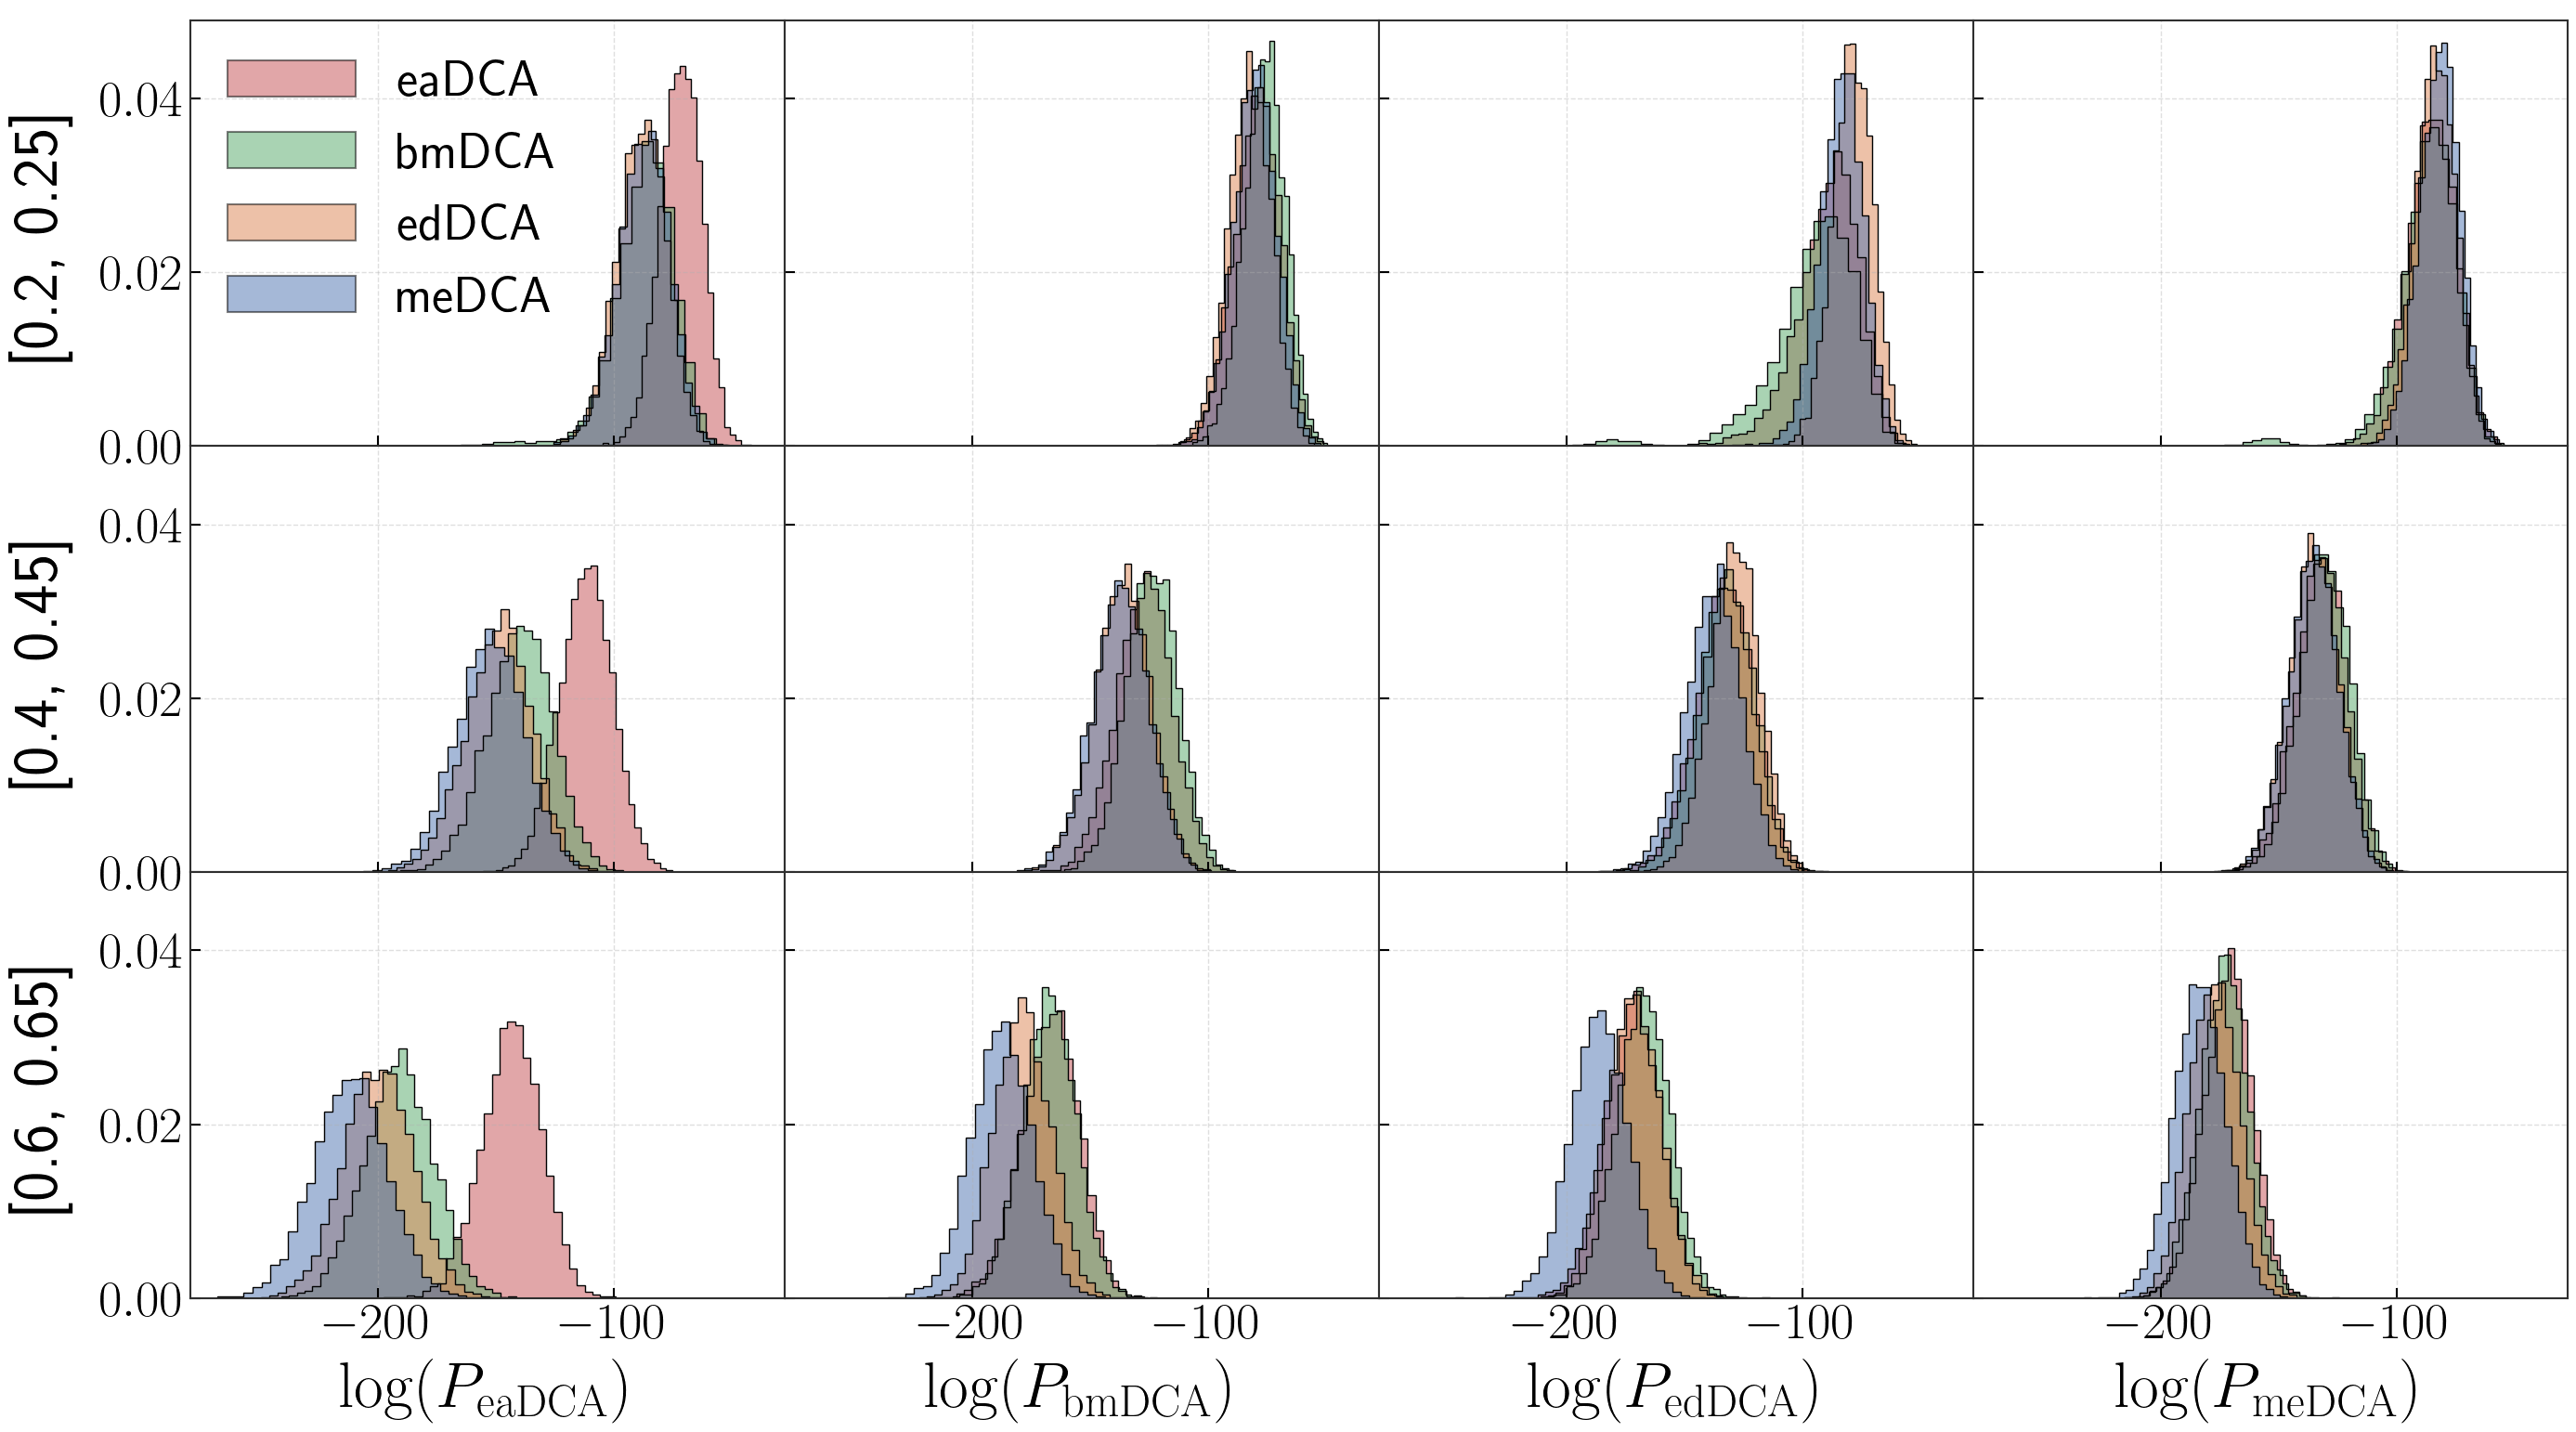

In [13]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch

def create_energy_distribution_panel(figsize=(32, 16)):
    """Create single plot (3x4) of energy distributions across all divergence intervals."""

    # === LaTeX style configuration ===
    plt.rcParams.update({
        "text.usetex": True,
        # "font.family": "serif",
        # "font.serif": ["Computer Modern Roman"],
        # "axes.linewidth": 1.2,
        # "xtick.direction": "in",
        # "ytick.direction": "in",
        # "xtick.top": True,
        # "ytick.right": True,
        # "xtick.major.size": 3.5,
        # "ytick.major.size": 3.5,
        # "xtick.minor.size": 2,
        # "ytick.minor.size": 2,
        # "axes.labelsize": 14,
        # "xtick.labelsize": 14,
        # "ytick.labelsize": 14,
        # "legend.frameon": False
    })

    # === Titles for each divergence level ===
    mask_titles = {
        1: r"[0.2, 0.25]",      # Low divergence
        2: r"[0.4, 0.45]",      # Medium divergence
        3: r"[0.6, 0.65]"       # High divergence
    }

    # === Model configuration ===
    models = ['eaDCA', 'bmDCA', 'edDCA', 'meDCA']
    colors_order = ['eaDCA', 'bmDCA', 'edDCA', 'meDCA']
    titles = ['eaDCA', 'bmDCA', 'edDCA', 'meDCA']

    # === Create 3x4 figure grid (3 rows = divergence levels, 4 columns = models) ===
    fig, axes = plt.subplots(3, 4, figsize=figsize, sharey=True, sharex=True)
    plt.subplots_adjust(wspace=0.0, hspace=0., left=0.06, right=0.86, top=0.94, bottom=0.08)

    # === Loop: 3 rows (divergence), 4 columns (models) ===
    for row_idx, mask_type in enumerate([1, 2, 3]):
        for col_idx, (model, color_key, title) in enumerate(zip(models, colors_order, titles)):
            ax = axes[row_idx, col_idx]

            # --- Load energy distributions ---
            ene_self = globals()[f'ene_{model}_{model}_{mask_type}']
            ene_eaDCA = globals()[f'ene_eaDCA_{model}_{mask_type}'] if model != 'eaDCA' else ene_self
            ene_bmDCA = globals()[f'ene_bmDCA_{model}_{mask_type}'] if model != 'bmDCA' else ene_self
            ene_edDCA = globals()[f'ene_edDCA_{model}_{mask_type}'] if model != 'edDCA' else ene_self
            ene_meDCA = globals()[f'ene_meDCA_{model}_{mask_type}'] if model != 'meDCA' else ene_self

            # --- Filled histograms for each model ---
            ax.hist(ene_eaDCA, bins=30, alpha=0.5, color=colors['eaDCA'],
                    density=True, label="eaDCA")
            ax.hist(ene_bmDCA, bins=30, alpha=0.5, color=colors['bmDCA'],
                    density=True, label="bmDCA")
            ax.hist(ene_edDCA, bins=30, alpha=0.5, color=colors['edDCA'],
                    density=True, label="edDCA")
            ax.hist(ene_meDCA, bins=30, alpha=0.5, color=colors['meDCA'],
                    density=True, label="meDCA")

            # --- Black contour outlines for each histogram ---
            for e, c in zip([ene_eaDCA, ene_bmDCA, ene_edDCA, ene_meDCA],
                            ["black"] * 4):
                ax.hist(e, bins=30, histtype='step', color=c, density=True, linewidth=1)

            # --- X-axis labels (bottom row only) ---
            if row_idx == 2:
                if col_idx == 0:
                    ax.set_xlabel(r"$\log(P_{\mathrm{eaDCA}})$", fontsize=50, labelpad=8)
                elif col_idx == 1:
                    ax.set_xlabel(r"$\log(P_{\mathrm{bmDCA}})$", fontsize=50, labelpad=8)
                elif col_idx == 2:
                    ax.set_xlabel(r"$\log(P_{\mathrm{edDCA}})$", fontsize=50, labelpad=8)
                elif col_idx == 3:
                    ax.set_xlabel(r"$\log(P_{\mathrm{meDCA}})$", fontsize=50, labelpad=8)

            # --- Row labels (left column only) ---
            if col_idx == 0:
                ax.text(-0.25, 0.5, mask_titles[mask_type],
                        fontsize=50, rotation=90, va='center', ha='center',
                        transform=ax.transAxes)

            # --- Axis styling ---
            ax.tick_params(axis='both', which='major', labelsize=40, direction='in', length=8, width=1.5)
            ax.tick_params(axis='both', which='minor', labelsize=40, direction='in', length=4, width=1)
            ax.grid(alpha=0.4, linestyle='--', linewidth=1)
            for spine in ax.spines.values():
                spine.set_linewidth(1.5)
                spine.set_color('#2F2F2F')

    # === External legend on the right side with black border on color boxes ===
    legend_order = ['eaDCA', 'bmDCA', 'edDCA', 'meDCA']
    legend_handles = [
        Patch(facecolor=colors[name], edgecolor='black', linewidth=1.5, alpha=0.5, label=name)
        for name in legend_order
    ]
    fig.legend(legend_handles, legend_order, loc='center right', fontsize=40,
               bbox_to_anchor=(0.21, 0.825), frameon=False, fancybox=False, shadow=False,
               framealpha=0.95, borderpad=1, handlelength=2.5, edgecolor="black")

    # === Save and show ===
    plt.savefig(output_path +"energy_distributions_fullpanel.pdf", bbox_inches='tight')
    plt.show()


# === Execute plotting function ===
create_energy_distribution_panel()


## Condensed Energy Distribution Panel

Generate a smaller LaTeX-style energy panel for the model comparisons most relevant to the manuscript narrative.


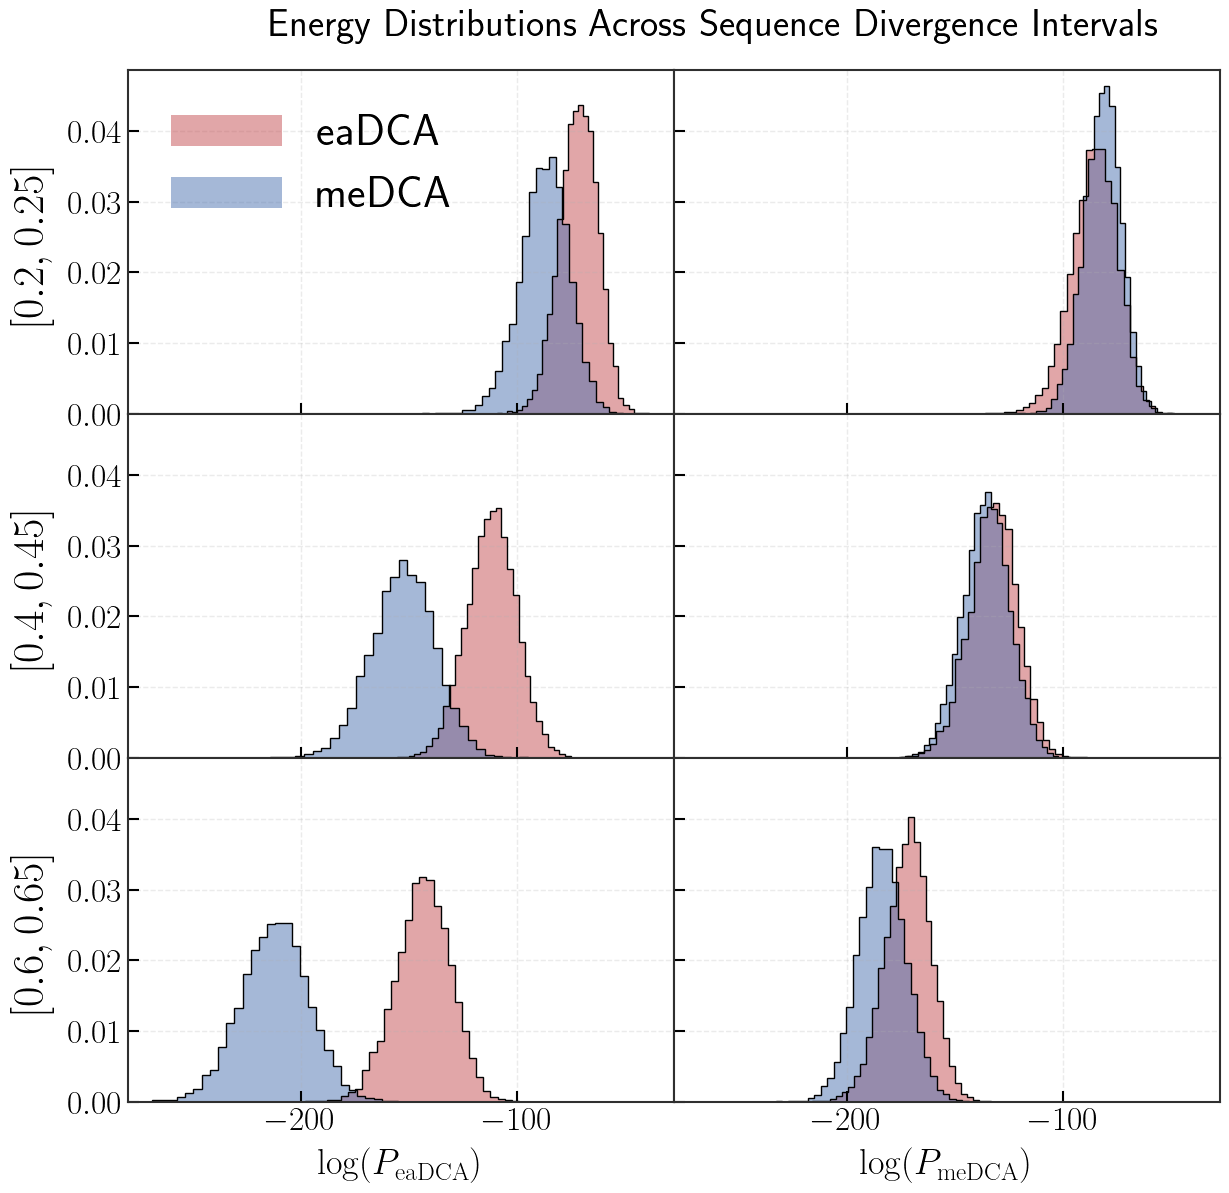

In [14]:
import matplotlib.pyplot as plt
import matplotlib as mpl

def create_energy_distribution_panel(figsize=(14, 12)):
    """Create single plot (3x2) of energy distributions in LaTeX style."""

    # === LaTeX style configuration ===
    plt.rcParams.update({
        "text.usetex": True,
        # "font.family": "serif",
        # "font.serif": ["Computer Modern Roman"],
        # "axes.linewidth": 1.2,
        # "xtick.direction": "in",
        # "ytick.direction": "in",
        # "xtick.top": True,
        # "ytick.right": True,
        # "xtick.major.size": 3.5,
        # "ytick.major.size": 3.5,
        # "xtick.minor.size": 2,
        # "ytick.minor.size": 2,
        # "axes.labelsize": 14,
        # "xtick.labelsize": 14,
        # "ytick.labelsize": 14,
        # "legend.frameon": False
    })

    # === Titles for each divergence level ===
    mask_titles = {
        1: r"$[0.2, 0.25]$",    # Low divergence
        2: r"$[0.4, 0.45]$",    # Medium divergence
        3: r"$[0.6, 0.65]$"     # High divergence
    }

    # === Models to compare ===
    models = ['eaDCA', 'meDCA']
    colors_order = ['eaDCA', 'meDCA']
    titles = [r"$\log(P_{\mathrm{eaDCA}})$", r"$\log(P_{\mathrm{meDCA}})$"]

    # === Create overall figure grid ===
    fig, axes = plt.subplots(3, 2, figsize=figsize, sharey=True, sharex=True)
    plt.subplots_adjust(wspace=0.0, hspace=0, left=0.08, right=0.86, top=0.94, bottom=0.08)

    legend_handles, legend_labels = [], []

    # === Main loop: 3 rows (divergence levels) x 2 columns (models) ===
    for row_idx, mask_type in enumerate([1, 2, 3]):
        for col_idx, (model, color_key, title) in enumerate(zip(models, colors_order, titles)):
            ax = axes[row_idx, col_idx]

            # --- Load energy distributions ---
            ene_self = globals()[f'ene_{model}_{model}_{mask_type}']
            ene_eaDCA = globals()[f'ene_eaDCA_{model}_{mask_type}'] if model != 'eaDCA' else ene_self
            ene_meDCA = globals()[f'ene_meDCA_{model}_{mask_type}'] if model != 'meDCA' else ene_self

            # --- Filled histograms ---
            ax.hist(ene_eaDCA, bins=30, alpha=0.5, color=colors['eaDCA'],
                    density=True, label=r"eaDCA")
            ax.hist(ene_meDCA, bins=30, alpha=0.5, color=colors['meDCA'],
                    density=True, label=r"meDCA")

            # --- Black contour outlines ---
            ax.hist(ene_eaDCA, bins=30, histtype='step', color="black", density=True, linewidth=1)
            ax.hist(ene_meDCA, bins=30, histtype='step', color="black", density=True, linewidth=1)

            # --- X-axis labels (bottom row only) ---
            if row_idx == 2:
                ax.set_xlabel(title, fontsize=26, labelpad=8)

            # --- Row side titles (left column only) ---
            if col_idx == 0:
                ax.text(-0.175, 0.5, mask_titles[mask_type],
                        fontsize=32, rotation=90, va='center', ha='center',
                        transform=ax.transAxes)

            # --- Axis styling ---
            ax.tick_params(axis='both', which='major', labelsize=24, direction='in', length=8, width=1.5)
            ax.tick_params(axis='both', which='minor', labelsize=24, direction='in', length=4, width=1)
            ax.grid(alpha=0.25, linestyle='--', linewidth=1)
            for spine in ax.spines.values():
                spine.set_linewidth(1.5)
                spine.set_color('#2F2F2F')

            # --- Collect legend handles (first subplot only) ---
            if row_idx == 0 and col_idx == 0:
                handles, labels = ax.get_legend_handles_labels()
                legend_handles.extend(handles)
                legend_labels.extend(labels)

    # === External legend on the right side ===
    fig.legend(legend_handles, legend_labels, loc='center right', fontsize=32,
               bbox_to_anchor=(0.36, 0.86), frameon=False, fancybox=False, shadow=False,
               framealpha=0.95, borderpad=1, handlelength=2.5)

    # === Overall title ===
    plt.suptitle(r"Energy Distributions Across Sequence Divergence Intervals",
                 fontsize=28, y=0.99)

    # === Save and show ===
    plt.savefig(output_path +"energy_distributions_panel_latex.pdf")
    plt.show()


# === Execute plotting function ===
create_energy_distribution_panel()


## Compact Energy Distribution Grid

Produce a compact grid version of the energy-distribution comparison for figure layouts with tighter space constraints.


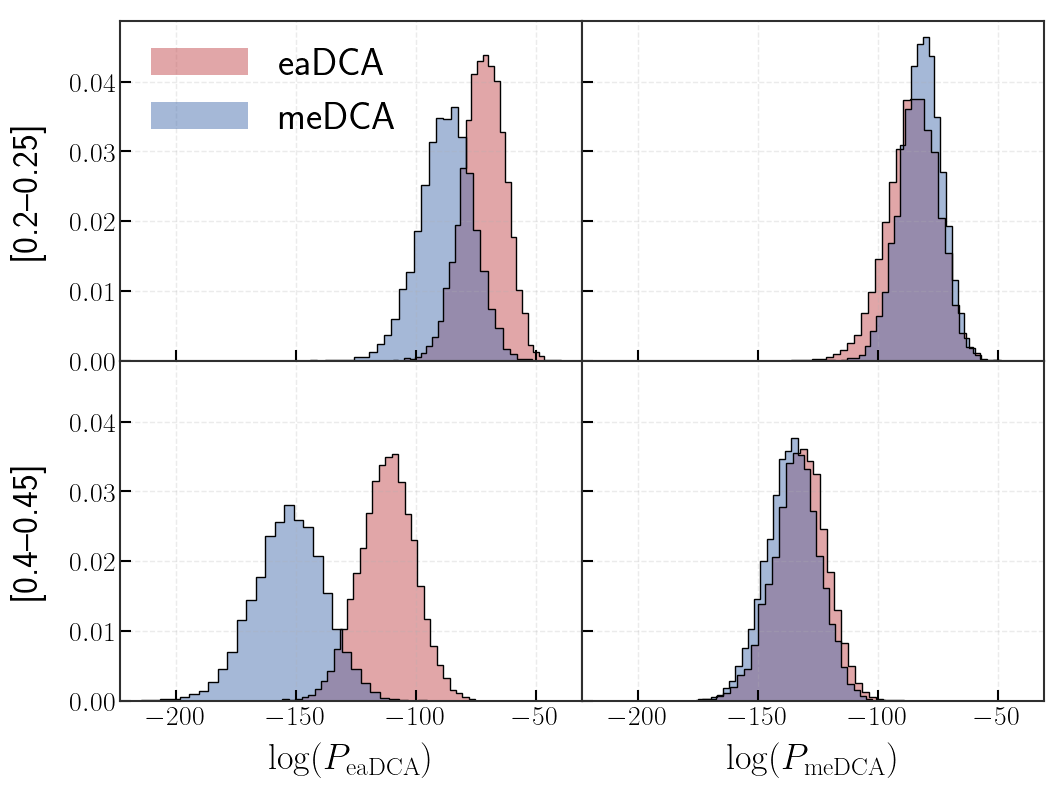

In [15]:
import matplotlib.pyplot as plt
import matplotlib as mpl

def create_energy_distribution_grid(figsize=(12, 8)):
    """Create compact grid of energy distributions in LaTeX style."""

    # === LaTeX style configuration with aesthetic settings ===
    plt.rcParams.update({
        "text.usetex": True,
        # "font.family": "serif",
        # "font.serif": ["Computer Modern Roman"],
        # "axes.linewidth": 1.2,
        # "xtick.direction": "in",
        # "ytick.direction": "in",
        # "xtick.top": True,
        # "ytick.right": True,
        # "xtick.major.size": 3.5,
        # "ytick.major.size": 3.5,
        # "xtick.minor.size": 2,
        # "ytick.minor.size": 2,
        # "axes.labelsize": 14,
        # "xtick.labelsize": 14,
        # "ytick.labelsize": 14,
        # "legend.frameon": False
    })

    # === Configuration parameters ===
    mask_titles = {1: "[0.2–0.25]", 2: "[0.4–0.45]"}  # Low and medium divergence
    models = ['eaDCA', 'meDCA']
    colors_order = ['eaDCA', 'meDCA']
    titles = ['eaDCA', 'meDCA']

    # === Create figure and grid ===
    fig, axes = plt.subplots(2, 2, figsize=figsize, sharey=True, sharex=True)
    plt.subplots_adjust(wspace=0.0, hspace=0.00, left=0.08, right=0.85, top=0.93, bottom=0.08)

    legend_handles, legend_labels = [], []

    # === Loop over rows (divergence) and columns (models) ===
    for row_idx, mask_type in enumerate([1, 2]):
        for col_idx, (model, color_key, title) in enumerate(zip(models, colors_order, titles)):
            ax = axes[row_idx, col_idx]

            # --- Load energy data ---
            ene_self = globals()[f'ene_{model}_{model}_{mask_type}']
            ene_eaDCA = globals()[f'ene_eaDCA_{model}_{mask_type}'] if model != 'eaDCA' else ene_self
            ene_meDCA = globals()[f'ene_meDCA_{model}_{mask_type}'] if model != 'meDCA' else ene_self

            # --- Filled histograms + contour outlines ---
            ax.hist(ene_eaDCA, bins=30, alpha=0.5, color=colors['eaDCA'],
                    density=True, label="eaDCA")
            ax.hist(ene_meDCA, bins=30, alpha=0.5, color=colors['meDCA'],
                    density=True, label="meDCA")

            ax.hist(ene_eaDCA, bins=30, histtype='step', color="black", density=True, linewidth=1)
            ax.hist(ene_meDCA, bins=30, histtype='step', color="black", density=True, linewidth=1)
            
            # --- X-axis labels (bottom row only) ---
            if row_idx == 1:
                xlabel = r"$\log(P_{\mathrm{eaDCA}})$" if col_idx == 0 else r"$\log(P_{\mathrm{meDCA}})$"
                ax.set_xlabel(xlabel, labelpad=8, fontsize=26)

            # --- Row side labels (left column only) ---
            if col_idx == 0:
                ax.text(-0.2, 0.5,
                        mask_titles[mask_type],
                        fontsize=26, rotation=90, va='center', ha='center',
                        transform=ax.transAxes)

            # --- Axis styling ---
            ax.tick_params(axis='both', which='major', labelsize=20, direction='in', length=8, width=1.5)
            ax.tick_params(axis='both', which='minor', labelsize=18, direction='in', length=4, width=1)
            ax.grid(alpha=0.25, linestyle='--', linewidth=1)
            for spine in ax.spines.values():
                spine.set_linewidth(1.5)
                spine.set_color('#2F2F2F')

            # --- Save handles for external legend (once only) ---
            if row_idx == 0 and col_idx == 0:
                handles, labels = ax.get_legend_handles_labels()
                legend_handles.extend(handles)
                legend_labels.extend(labels)

    # === External legend ===
    fig.legend(legend_handles, legend_labels, loc='center right', fontsize=28,
               bbox_to_anchor=(0.36, 0.84), frameon=False, fancybox=False, shadow=False,
               framealpha=0.95, borderpad=1, handlelength=2.5)

    # === Save figure ===
    plt.savefig(output_path +"energy_distributions_grid_compact_latex.pdf", bbox_inches='tight')
    plt.show()


# === Execute plotting function ===
create_energy_distribution_grid()


# Entropy Dynamics

This section analyzes how entropy changes along model-decimation trajectories.


## Entropy Along Decimation

Plot entropy values along the decimation path to show how model sparsification changes the entropy of sampled sequences.


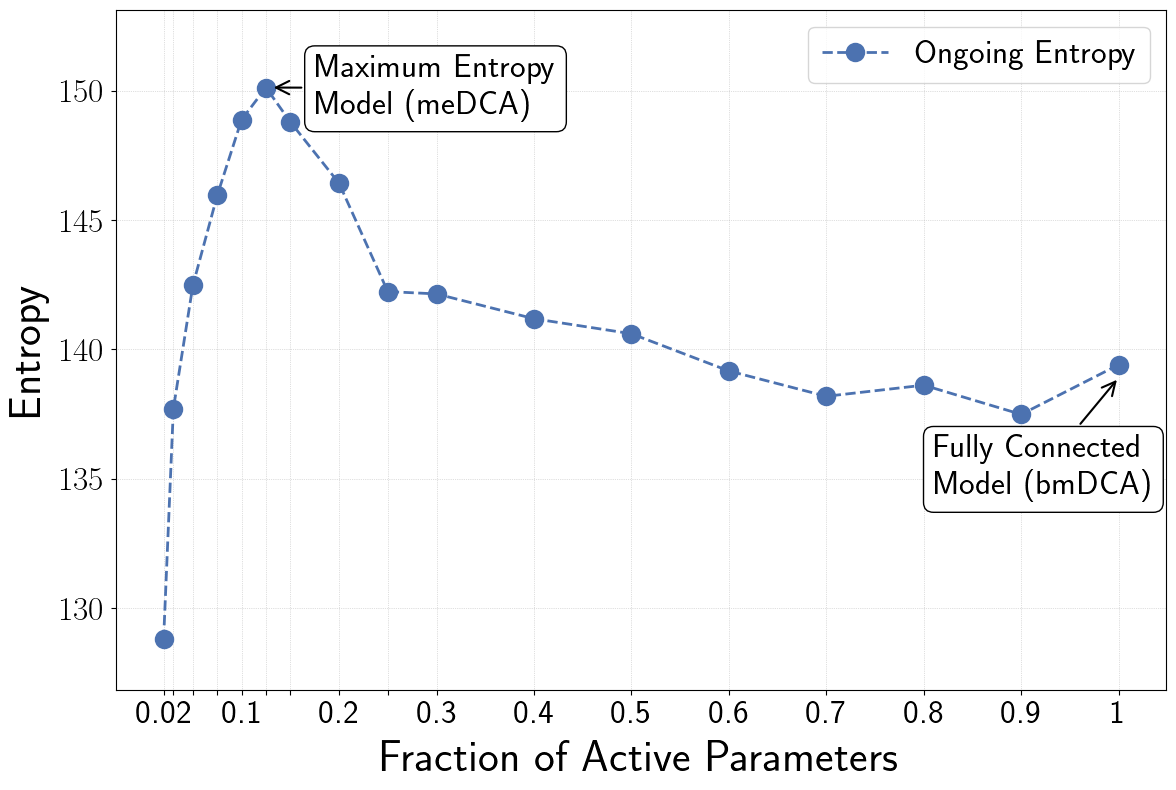

In [16]:
# ===============================================================================
# ENTROPY DYNAMICS ALONG DECIMATION PATH
# ===============================================================================
# This plot shows how entropy evolves as model complexity decreases along the
# decimation path from fully-connected bmDCA to maximum-entropy meDCA.
# The x-axis shows the fraction of active (non-zero) parameters.
# ===============================================================================

# Data: complexity (fraction of active parameters) vs entropy
complexities = np.array([1,  0.9,     0.8,    0.7,   0.6,     0.5,    0.4,    0.3,      0.25,   0.2,     0.15,   0.125,  0.1,    0.075,  0.05,   0.03,   0.02])
entropies = np.array([139.41, 137.49, 138.62, 138.19, 139.17, 140.61, 141.19,  142.15,  142.24, 146.43,  148.80, 150.13, 148.89, 145.96, 142.48, 137.71, 128.82])

# Convert complexities to percentages for clarity (e.g., 1 → 100%)
x_perc = complexities * 100

# Custom x-axis labels (sparse labeling for readability)
xtick_labels = ["1", "0.9", "0.8", "0.7", "0.6", "0.5", "0.4", "0.3", "", "0.2", "", "", "0.1", "", "", "", "0.02"]
xtick_values = x_perc
plt.rcParams.update({
        "text.usetex": True})
# === Enhanced plot configuration ===
fig, ax = plt.subplots(figsize=(12, 8))  # Slightly reduced height for compactness

# Main line plot with thicker width and visible markers
ax.plot(x_perc, entropies, marker='o', linestyle='--', linewidth=2, markersize=12,
        markerfacecolor=colors['meDCA'], markeredgewidth=2, label="Ongoing Entropy", color=colors['meDCA'])

# === Axis labels and title ===
ax.set_xlabel("Fraction of Active Parameters", fontsize=32, labelpad=8)
ax.set_ylabel("Entropy", fontsize=32, labelpad=8)

# === Custom tick configuration ===
ax.set_xticks(xtick_values)
ax.set_xticklabels(xtick_labels, fontsize=24)
ax.tick_params(axis='y', labelsize=24, which='major')
ax.tick_params(axis='x', rotation=0)  # Can use rotation=30 if labels overlap

# === Annotation: Fully Connected Model (bmDCA) ===
ax.annotate(
    "Fully Connected\nModel (bmDCA)", 
    xy=(90+10, entropies[0]-0.5),  # Point to annotate
    xytext=(90 - 9, entropies[0] - 5),  # Text position
    arrowprops=dict(arrowstyle="->", linewidth=1.5),
    fontsize=24,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1)
)

# === Annotation: Maximum Entropy Model (meDCA) ===
ax.annotate(
    "Maximum Entropy\nModel (meDCA)", 
    xy=(13, max(entropies)),  # Point to annotate (peak entropy)
    xytext=(12.5 + 5, max(entropies) - 1),  # Text position
    arrowprops=dict(arrowstyle="->", linewidth=1.5),
    fontsize=24,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1)
)

# === Grid and minor ticks ===
ax.grid(True, which='major', linestyle=':', linewidth=0.7)
ax.grid(True, linestyle=':', linewidth=0.5, alpha=0.8)

# === Legend configuration ===
ax.legend(frameon=True, fontsize=24, loc='upper right')

# === Axis limits with padding ===
ax.set_ylim(entropies.min() - 2, entropies.max() + 3)

plt.tight_layout()
plt.savefig(output_path +"entropy_decimated_models_vs_density_improved.pdf")
plt.show()


# Average Position Log-Likelihood

This section reports the average self log-likelihood per sequence position for each model, computed from the corresponding `logP_model_model` array and normalized by sequence length.


In [17]:
# Average self log-likelihood per sequence position for each model
sequence_length = 96
model_order = ['eaDCA', 'bmDCA', 'edDCA', 'meDCA']

self_logP = {
    'eaDCA': logP_eaDCA_eaDCA,
    'bmDCA': logP_bmDCA_bmDCA,
    'edDCA': logP_edDCA_edDCA,
    'meDCA': logP_meDCA_meDCA,
}

average_position_log_likelihood = pd.DataFrame(
    {
        'model': model_order,
        'average_position_log_likelihood': [
            np.mean(self_logP[model]) / sequence_length for model in model_order
        ],
    }
)

average_position_log_likelihood


,model,average_position_log_likelihood
0,eaDCA,-1.178158
1,bmDCA,-1.271278
2,edDCA,-1.417768
3,meDCA,-1.562290


## Combined Summary Figure

Assemble the entropy and effective-sequence-number panels side by side while preserving their original proportions.


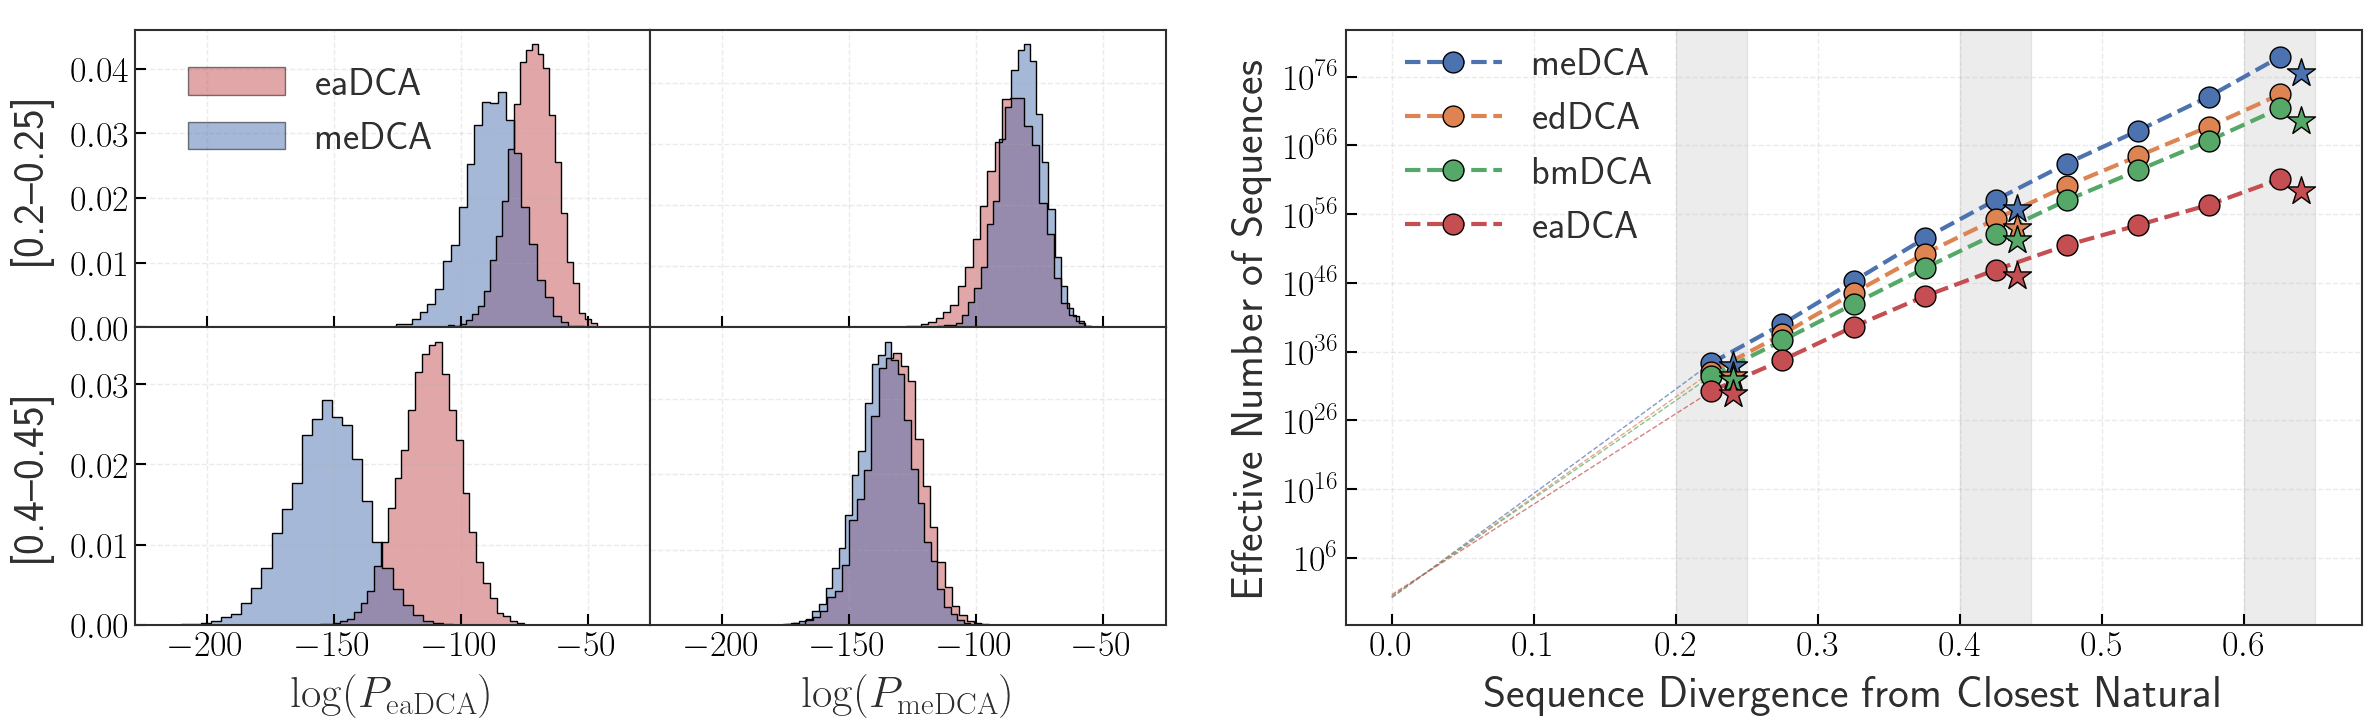

In [18]:
# ==============================================================================
# COMBINED FIGURE: original proportions preserved side by side
# ==============================================================================

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.rcParams.update({
    "text.usetex": True,
    "font.weight": "normal",
    "axes.labelweight": "normal",
    "axes.titleweight": "normal",
})

TEXT_COLOR = "#2F2F2F"


def panel_to_figure(bounds, panel_bounds):
    x, y, w, h = bounds
    px, py, pw, ph = panel_bounds
    return [px + x * pw, py + y * ph, w * pw, h * ph]


def style_tick_labels(ax, xtick_size=None, ytick_size=None):
    if xtick_size is not None:
        for label in ax.get_xticklabels():
            label.set_fontsize(xtick_size)
            label.set_fontweight("normal")
    if ytick_size is not None:
        for label in ax.get_yticklabels():
            label.set_fontsize(ytick_size)
            label.set_fontweight("normal")


def plot_effective_sequences(ax):
    x_plot = [0.225, 0.275, 0.325, 0.375, 0.425, 0.475, 0.525, 0.575, 0.625]
    x_star = [0.24, 0.44, 0.64]

    series_config = [
        ("meDCA", S_msa_meDCA, S_meDCA_interval, f_rate_meDCA),
        ("edDCA", S_msa_edDCA, S_edDCA_interval, f_rate_edDCA),
        ("bmDCA", S_msa_bmDCA, S_bmDCA_interval, f_rate_bmDCA),
        ("eaDCA", S_msa_eaDCA, S_eaDCA_interval, f_rate_eaDCA),
    ]

    for model, S_msa, S_interval, f_rate in series_config:
        x_bridge = np.array([0, 0.225])
        y_bridge = np.exp(np.array([S_msa, S_interval[0]]))
        ax.plot(x_bridge, y_bridge, linestyle="--", c=colors[model], linewidth=1, alpha=0.7)
        ax.plot(
            x_plot,
            np.exp(S_interval),
            marker="o",
            markersize=15,
            linewidth=3,
            c=colors[model],
            label=model,
            markeredgewidth=1,
            markeredgecolor="black",
            linestyle="--",
        )

        y_star = np.array([
            np.exp(S_interval[0]) * f_rate[0],
            np.exp(S_interval[4]) * f_rate[1],
            np.exp(S_interval[8]) * f_rate[2],
        ])
        ax.scatter(
            x_star,
            y_star,
            marker="*",
            s=450,
            c=[colors[model]],
            edgecolors="black",
            linewidth=1,
            zorder=10,
        )

    ax.set_xlabel("Sequence Divergence from Closest Natural", fontsize=32, labelpad=10, fontweight="normal", color=TEXT_COLOR)
    ax.set_ylabel("Effective Number of Sequences", fontsize=32, labelpad=10, fontweight="normal", color=TEXT_COLOR)
    ax.axvspan(0.2, 0.25, color="gray", alpha=0.15, zorder=0)
    ax.axvspan(0.40, 0.45, color="gray", alpha=0.15, zorder=0)
    ax.axvspan(0.60, 0.65, color="gray", alpha=0.15, zorder=0)
    ax.set_yscale("log")

    legend = ax.legend(
        prop={"size": 28, "weight": "normal"},
        frameon=False,
        fancybox=False,
        shadow=False,
        framealpha=0.95,
        loc="upper left",
        bbox_to_anchor=(0.02, 1.035),
        borderaxespad=0.0,
        borderpad=1,
        handlelength=2.5,
    )
    for text in legend.get_texts():
        text.set_color(TEXT_COLOR)

    ax.grid(True, alpha=0.25, linestyle="--", linewidth=1)
    ax.tick_params(axis="both", which="major", labelsize=16, direction="in", length=8, width=1.5)
    ax.tick_params(axis="both", which="minor", labelsize=14, direction="in", length=4, width=1)
    style_tick_labels(ax, xtick_size=26, ytick_size=26)

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color("#2F2F2F")


def get_effective_axes_bounds():
    temp_fig = plt.figure(figsize=(12, 7))
    temp_ax = temp_fig.add_subplot(111)
    plot_effective_sequences(temp_ax)
    temp_fig.tight_layout()
    bounds = temp_ax.get_position().bounds
    plt.close(temp_fig)
    return bounds


fig = plt.figure(figsize=(24, 7))
left_panel = [0.0, 0.0, 10.5 / 22.5, 1.0]

# --- Left plot: compact 12x8 energy grid ---
mask_titles = {1: "[0.2–0.25]", 2: "[0.4–0.45]"}
models = ["eaDCA", "meDCA"]
titles = ["eaDCA", "meDCA"]
legend_handles, legend_labels = [], []
left_axes = []
shared_x_min = np.inf
shared_x_max = -np.inf

left_margin = 0.08
right_margin = 1
bottom_margin = 0.08
top_margin = 0.93
col_width = (right_margin - left_margin) / 2
row_height = (top_margin - bottom_margin) / 2

for row_idx, mask_type in enumerate([1, 2]):
    for col_idx, (model, title) in enumerate(zip(models, titles)):
        panel_x = left_margin + col_idx * col_width
        panel_y = bottom_margin + (1 - row_idx) * row_height
        ax = fig.add_axes(panel_to_figure([panel_x, panel_y, col_width, row_height], left_panel))
        left_axes.append(ax)

        ene_self = globals()[f"ene_{model}_{model}_{mask_type}"]
        ene_eaDCA = globals()[f"ene_eaDCA_{model}_{mask_type}"] if model != "eaDCA" else ene_self
        ene_meDCA = globals()[f"ene_meDCA_{model}_{mask_type}"] if model != "meDCA" else ene_self
        shared_x_min = min(shared_x_min, np.min(ene_eaDCA), np.min(ene_meDCA))
        shared_x_max = max(shared_x_max, np.max(ene_eaDCA), np.max(ene_meDCA))

        ax.hist(ene_eaDCA, bins=30, alpha=0.5, color=colors["eaDCA"], density=True, label="eaDCA")
        ax.hist(ene_meDCA, bins=30, alpha=0.5, color=colors["meDCA"], density=True, label="meDCA")
        ax.hist(ene_eaDCA, bins=30, histtype="step", color="black", density=True, linewidth=1)
        ax.hist(ene_meDCA, bins=30, histtype="step", color="black", density=True, linewidth=1)

        if row_idx == 1:
            xlabel = r"$\log(P_{\mathrm{eaDCA}})$" if col_idx == 0 else r"$\log(P_{\mathrm{meDCA}})$"
            ax.set_xlabel(xlabel, labelpad=8, fontsize=32, color=TEXT_COLOR)

        if col_idx == 0:
            ax.text(
                -0.2,
                0.5,
                mask_titles[mask_type],
                fontsize=32,
                color=TEXT_COLOR,
                rotation=90,
                va="center",
                ha="center",
                transform=ax.transAxes,
            )

        ax.tick_params(axis="both", which="major", labelsize=16, direction="in", length=8, width=1.5)
        ax.tick_params(axis="both", which="minor", labelsize=14, direction="in", length=4, width=1)
        if col_idx == 1:
            ax.tick_params(axis="y", which="both", left=False, labelleft=False)
        style_tick_labels(ax, xtick_size=26, ytick_size=26)
        ax.grid(alpha=0.25, linestyle="--", linewidth=1)
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
            spine.set_color("#2F2F2F")

        if row_idx == 0 and col_idx == 0:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

x_padding = 0.08 * (shared_x_max - shared_x_min)
for ax in left_axes:
    ax.set_xlim(shared_x_min - x_padding, shared_x_max + x_padding)

legend_handles = [
    Patch(facecolor=colors["eaDCA"], edgecolor="black", linewidth=1, alpha=0.5, label="eaDCA"),
    Patch(facecolor=colors["meDCA"], edgecolor="black", linewidth=1, alpha=0.5, label="meDCA"),
]
legend_labels = ["eaDCA", "meDCA"]
left_legend = fig.legend(
    legend_handles,
    legend_labels,
    loc="upper right",
    fontsize=28,
    bbox_to_anchor=(left_panel[0] + 0.4 * left_panel[2], bottom_margin + 1.035 * (top_margin - bottom_margin)),
    frameon=False,
    fancybox=False,
    shadow=False,
    framealpha=0.95,
    borderpad=1,
    handlelength=2.5,
)
for text in left_legend.get_texts():
    text.set_color(TEXT_COLOR)

# --- Right plot: resized to align the axes box with the left grid ---
left_grid_right = left_panel[0] + right_margin * left_panel[2]
right_axes_left = left_grid_right + 0.075
right_axes_bounds = [right_axes_left, bottom_margin, 0.965 - right_axes_left, top_margin - bottom_margin]
ax_right = fig.add_axes(right_axes_bounds)
plot_effective_sequences(ax_right)

plt.savefig(output_path + "energy_and_effective_sequences_combined.pdf", bbox_inches="tight", pad_inches=0.2)
plt.show()
